In [1]:
from dataclasses import replace

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib as mplib
import matplotlib.pyplot as plt
import numpy as np
import optax
import shapely.geometry as shap_geom
from flax import nnx
from shapely.prepared import prep

import moto.src.bc as _bc
import moto.src.cons_loss as _cons_loss
import moto.src.ext_force as _ext_force
import moto.src.geometry as _geom
import moto.src.material as _mat
import moto.src.material_points as _mp
import moto.src.mesher as _mesher
import moto.src.mpm_elem_map as _mpm_elem_map
import moto.src.network as _net
import moto.src.nl_solver as _nlsolv
import moto.src.solve as _solve
import moto.src.utils as _utils
import moto.src.viz as _viz
from moto.src.hyperelastic_mpm import HyperelasticMPM, StructField

_Ext = _utils.Extent

jax.config.update("jax_enable_x64", True)
GIF_DIR = "frames"
GIF_PATH = "mpm.gif"
GIF_FPS = 3
frames = []

_Field = StructField

/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:22: UserWarning: petsc4py library not found. PETSc solver is not available.
  warnings.warn("petsc4py library not found. PETSc solver is not available.")
/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:27: UserWarning: pypardiso library not found. Some solvers may not be available.
  warnings.warn("pypardiso library not found. Some solvers may not be available.")


## Geometry & Mesh

In [3]:
bbox = _geom.BrepGeometry("../brep/rect_domain_expt_5.json")
gripper_bbox = _geom.BrepGeometry("../brep/gripper_expt_5.json")
mesh = _mesher.grid_mesh_brep(
  brep=bbox,
  nelx_desired=80,
  nely_desired=40,
  dofs_per_node=2,
  gauss_order=2,
)

## Material Points Generation 


In [4]:
prepared_beam_geom = prep(gripper_bbox.geometry)
inside = np.array(
  [prepared_beam_geom.covers(shap_geom.Point(xy)) for xy in mesh.elem_centers],
  dtype=bool,
)

# Element IDs to populate
occupied_element_ids = np.where(inside)[0]

# MPs
num_mp_per_elem_per_dim = 4
mp_coords = _mesher.generate_mp_coords_in_occupied_elements(
  mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)
num_mat_pts = mp_coords.shape[0]

In [5]:
# ============================================
# EXTRACT VERTICES FROM BREP DIRECTLY
geom = gripper_bbox.geometry
if hasattr(geom, "exterior"):
  coords_list = list(geom.exterior.coords)
else:
  geoms = [g for g in getattr(geom, "geoms", []) if hasattr(g, "exterior")]
  coords_list = list(geoms[0].exterior.coords)

vertices = np.array(coords_list[:-1])
print("BREP Vertices:")
for i, v in enumerate(vertices):
  print(f"  V{i}: ({v[0]:.4f}, {v[1]:.4f})")

# ============================================
# IDENTIFY KEY VERTICES BY GEOMETRY
# Input: highest y (top of vertical edge)
input_idx = np.argmax(vertices[:, 1])
input_vertex = vertices[input_idx]

output_idx = np.argmin(vertices[:, 1])
output_vertex = vertices[output_idx]

# Clamp: rightmost x, lower portion (junction area)
# Find vertex with max x but not the input
right_vertices = vertices[vertices[:, 0] == vertices[:, 0].max()]
clamp_vertex = right_vertices[np.argmin(right_vertices[:, 1])]

print(f"\nKey positions:")
print(f"  Input (top):    ({input_vertex[0]:.4f}, {input_vertex[1]:.4f})")
print(f"  Output (bottom): ({output_vertex[0]:.4f}, {output_vertex[1]:.4f})")
print(f"  Clamp (right-low): ({clamp_vertex[0]:.4f}, {clamp_vertex[1]:.4f})")

# ============================================
# COMPUTE EDGE DIRECTIONS
edge_start = output_vertex
edge_end = vertices[(output_idx + 2) % len(vertices)]  # Next vertex

edge_vec = edge_end - edge_start
edge_length = np.linalg.norm(edge_vec)
edge_dir = edge_vec / edge_length

# Perpendicular to edge
perp_dir = np.array([edge_dir[1], -edge_dir[0]])

# Make sure perpendicular points away from gripper centroid
centroid = np.mean(vertices, axis=0)
test_point = edge_start + 0.01 * perp_dir
if np.linalg.norm(test_point - centroid) < np.linalg.norm(edge_start - centroid):
  perp_dir = -perp_dir  # Flip if pointing toward centroid

print(f"\n45° Edge direction: ({edge_dir[0]:.3f}, {edge_dir[1]:.3f})")
print(f"Perpendicular (outward): ({perp_dir[0]:.3f}, {perp_dir[1]:.3f})")


BREP Vertices:
  V0: (0.0500, 0.0283)
  V1: (0.1066, 0.0849)
  V2: (0.1136, 0.0919)
  V3: (0.1136, 0.1909)
  V4: (0.0089, 0.0694)

Key positions:
  Input (top):    (0.1136, 0.1909)
  Output (bottom): (0.0500, 0.0283)
  Clamp (right-low): (0.1136, 0.0919)

45° Edge direction: (0.707, 0.707)
Perpendicular (outward): (0.707, -0.707)


# Non design Solid region

In [6]:
hx, hy = map(float, np.asarray(mesh.elem_size))
face_tol = 0.5 * max(hx, hy)
xminG, yminG, xmaxG, ymaxG = gripper_bbox.geometry.bounds
nd_width_in = 0.005
nd_width_out = 0.002
# Non-design: from start to past the clamp end
t_start = 0.0
t_end = 1.05

p1 = edge_start + t_start * edge_vec
p2 = edge_start + t_end * edge_vec

# Extend in BOTH directions from the edge
p1_out = p1 + nd_width_out * perp_dir
p2_out = p2 + nd_width_out * perp_dir

p1_in = p1 - nd_width_in * perp_dir
p2_in = p2 - nd_width_in * perp_dir

nd_polygon = shap_geom.Polygon([p1_out, p2_out, p2_in, p1_in, p1_out])

# Find MPs in non-design region
solid_id = 0
mp_xy = np.asarray(mp_coords)
mask_nd = np.array([nd_polygon.contains(shap_geom.Point(xy)) for xy in mp_xy])
nd_ids_np = np.where(mask_nd)[0].astype(np.int32)
nd_ids = jnp.asarray(nd_ids_np)
print(f"Non-design MPs: {nd_ids.size}")


Non-design MPs: 662


# Boundary conditions

In [7]:
# --------------------------
# CLAMP: At clamp_vertex
clamp_x, clamp_y = clamp_vertex

clamp_bbox = _mesher.BoundingBox(
  x=_Ext(min=clamp_x - 2 * face_tol, max=clamp_x + 3 * face_tol),
  y=_Ext(min=clamp_y - 2 * face_tol, max=clamp_y + 3 * face_tol),
)
mask_clamp_nodes = _mesher.compute_point_indices_in_box(
  np.asarray(mesh.nodes.coords), clamp_bbox
)
clamp_nodes = np.where(np.asarray(mask_clamp_nodes))[0]
if clamp_nodes.size == 0:
  raise ValueError("No nodes in clamp bbox")

fixed_dofs_clamp = np.r_[2 * clamp_nodes, 2 * clamp_nodes + 1].astype(np.int32)
print(f"Clamp nodes: {clamp_nodes.size} at ({clamp_x:.4f}, {clamp_y:.4f})")

# --------------------------
# ROLLER at INPUT
input_x, input_y = input_vertex

roller_input_bbox = _mesher.BoundingBox(
  x=_Ext(min=input_x - 2 * face_tol, max=input_x + 2 * face_tol),
  y=_Ext(min=input_y - 2 * face_tol, max=input_y + 2 * face_tol),
)
mask_roller_input = _mesher.compute_point_indices_in_box(
  np.asarray(mesh.nodes.coords), roller_input_bbox
)
roller_input_nodes = np.where(np.asarray(mask_roller_input))[0]
if roller_input_nodes.size == 0:
  raise ValueError("No nodes in input roller bbox")

fixed_dofs_roller_input = (2 * roller_input_nodes).astype(np.int32)  # X only
print(
  f"Input roller nodes: {roller_input_nodes.size} at ({input_x:.4f}, {input_y:.4f})"
)

# --------------------------
# Combine all fixed DOFs
fixed_dofs = np.unique(
  np.r_[
    fixed_dofs_clamp,
    fixed_dofs_roller_input,
  ]
).astype(np.int32)

all_dofs = np.arange(mesh.num_dofs, dtype=np.int32)
free_dofs = np.setdiff1d(all_dofs, fixed_dofs).astype(np.int32)

bc = {
  "fixed_dofs": jnp.asarray(fixed_dofs),
  "free_dofs": jnp.asarray(free_dofs),
}
print(f"Total fixed DOFs: {fixed_dofs.size}")


Clamp nodes: 10 at (0.1136, 0.0919)
Input roller nodes: 8 at (0.1136, 0.1909)
Total fixed DOFs: 28


#  Forces on material points

In [8]:
x_in, y_in = input_vertex

in_bbox = _mesher.BoundingBox(
  x=_Ext(min=x_in - 2 * face_tol, max=x_in + 2 * face_tol),
  y=_Ext(min=y_in - 2 * face_tol, max=y_in + 2 * face_tol),
)
mask_in = _mesher.compute_point_indices_in_box(np.asarray(mp_coords), in_bbox)
in_ids = np.where(np.asarray(mask_in))[0]
if in_ids.size == 0:
  raise ValueError("No MPs found in input bbox")

F_in_total = -10.0  # Negative y = downward

mp_force_in = jnp.zeros((num_mat_pts, mesh.num_dim), dtype=jnp.float64)
mp_force_in = mp_force_in.at[in_ids, 1].set(F_in_total / in_ids.size)

print(f"\nInput force at ({x_in:.4f}, {y_in:.4f})")
print(f"  MPs: {in_ids.size}, Force: (0, {F_in_total}) - DOWN")



Input force at (0.1136, 0.1909)
  MPs: 12, Force: (0, -10.0) - DOWN


# Virtual Force

In [9]:
x_out, y_out = output_vertex

out_bbox = _mesher.BoundingBox(
  x=_Ext(min=x_out - 2 * face_tol, max=x_out + 2 * face_tol),
  y=_Ext(min=y_out - 3 * face_tol, max=y_out + 2 * face_tol),
)
mask_out = _mesher.compute_point_indices_in_box(np.asarray(mp_coords), out_bbox)
out_ids = np.where(np.asarray(mask_out))[0]
if out_ids.size == 0:
  raise ValueError("No MPs found in output bbox")

out_ids = jnp.asarray(out_ids)

# Force PERPENDICULAR to edge, pointing toward workpiece (outward)
F_out_magnitude = 10.0
F_out_x = F_out_magnitude * perp_dir[0]
F_out_y = F_out_magnitude * perp_dir[1]

mp_force_out = jnp.zeros((num_mat_pts, mesh.num_dim), dtype=jnp.float64)
mp_force_out = mp_force_out.at[out_ids, 0].set(F_out_x / out_ids.size)
mp_force_out = mp_force_out.at[out_ids, 1].set(F_out_y / out_ids.size)

print(f"\nOutput force at ({x_out:.4f}, {y_out:.4f})")
print(f"  MPs: {out_ids.size}")
print(f"  Force direction: ({F_out_x:.3f}, {F_out_y:.3f}) - perpendicular to edge")



Output force at (0.0500, 0.0283)
  MPs: 48
  Force direction: (7.071, -7.071) - perpendicular to edge


## Visualization

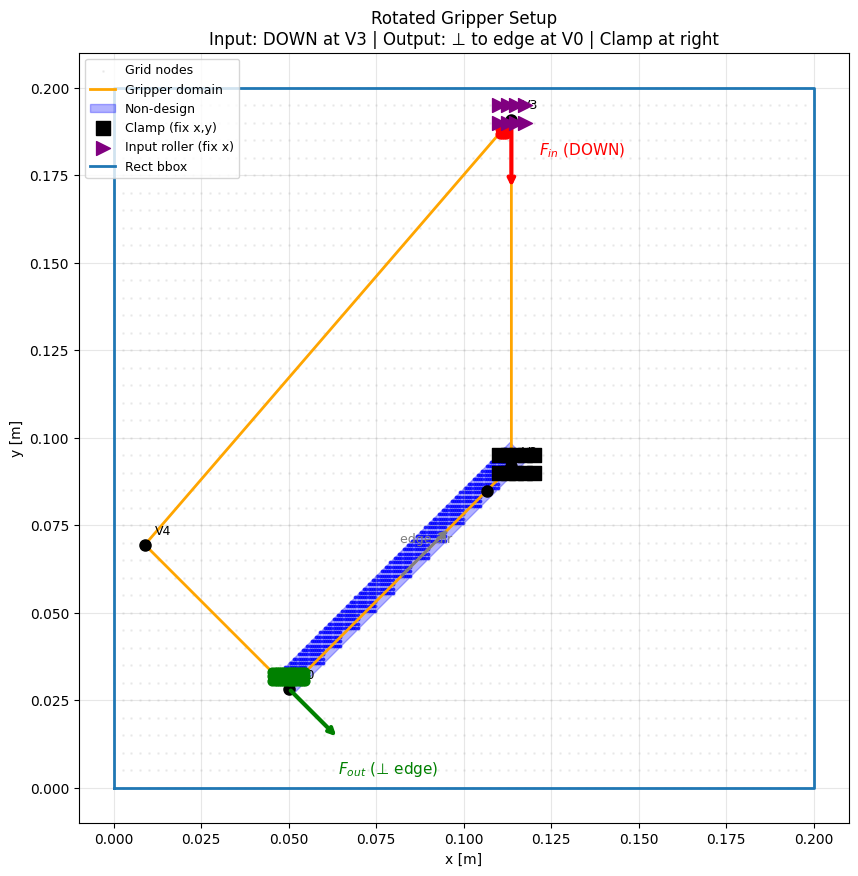

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

Xn = np.asarray(mesh.nodes.coords)
mp_xy = np.asarray(mp_coords)

# All grid nodes
ax.scatter(Xn[:, 0], Xn[:, 1], s=1, c="lightgray", alpha=0.3, label="Grid nodes")

# Gripper polygon (orange)
xs_grip, ys_grip = (
  geom.exterior.xy if hasattr(geom, "exterior") else geoms[0].exterior.xy
)
ax.plot(xs_grip, ys_grip, "orange", lw=2, label="Gripper domain")

# Non-design region (blue)
if nd_ids.size > 0:
  xs_nd, ys_nd = nd_polygon.exterior.xy
  ax.fill(xs_nd, ys_nd, alpha=0.3, color="blue", label="Non-design")
  ax.scatter(mp_xy[nd_ids, 0], mp_xy[nd_ids, 1], s=3, c="blue", alpha=0.7)

# Clamp (black squares)
ax.scatter(
  Xn[clamp_nodes, 0],
  Xn[clamp_nodes, 1],
  s=100,
  c="black",
  marker="s",
  label="Clamp (fix x,y)",
  zorder=10,
)

# Input roller (purple triangles)
ax.scatter(
  Xn[roller_input_nodes, 0],
  Xn[roller_input_nodes, 1],
  s=100,
  c="purple",
  marker=">",
  label="Input roller (fix x)",
  zorder=10,
)

# Input force (red) - pointing DOWN
ax.scatter(mp_xy[in_ids, 0], mp_xy[in_ids, 1], s=40, c="red", zorder=5)
arrow_len = 0.02
ax.annotate(
  "",
  xy=(x_in, y_in - arrow_len),
  xytext=(x_in, y_in),
  arrowprops=dict(arrowstyle="->", color="red", lw=3),
)
ax.text(x_in + 0.008, y_in - arrow_len / 2, "$F_{in}$ (DOWN)", fontsize=11, color="red")

# Output force (green) - pointing PERPENDICULAR to edge
ax.scatter(mp_xy[out_ids, 0], mp_xy[out_ids, 1], s=40, c="green", zorder=5)
ax.annotate(
  "",
  xy=(x_out + arrow_len * perp_dir[0], y_out + arrow_len * perp_dir[1]),
  xytext=(x_out, y_out),
  arrowprops=dict(arrowstyle="->", color="green", lw=3),
)
ax.text(
  x_out + arrow_len * perp_dir[0],
  y_out + arrow_len * perp_dir[1] - 0.01,
  "$F_{out}$ (⊥ edge)",
  fontsize=11,
  color="green",
)

# Mark all BREP vertices
for i, v in enumerate(vertices):
  ax.plot(v[0], v[1], "ko", markersize=8)
  ax.text(v[0] + 0.003, v[1] + 0.003, f"V{i}", fontsize=9, color="black")

# Draw the 45° edge direction
mid_edge = 0.5 * (edge_start + edge_end)
ax.annotate(
  "",
  xy=mid_edge + 0.02 * edge_dir,
  xytext=mid_edge,
  arrowprops=dict(arrowstyle="->", color="gray", lw=2),
)
ax.text(mid_edge[0], mid_edge[1] + 0.01, "edge dir", fontsize=9, color="gray")


# Rect bbox
def plot_bbox_fn(ax, bb, label):
  xmin, ymin, xmax, ymax = bb.geometry.bounds
  ax.plot(
    [xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], lw=2, label=label
  )


plot_bbox_fn(ax, bbox, "Rect bbox")

ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(
  "Rotated Gripper Setup\n"
  f"Input: DOWN at V{input_idx} | Output: ⊥ to edge at V{output_idx} | Clamp at right"
)
plt.grid(True, alpha=0.3)
plt.show()

## Material Initialization

In [11]:
youngs_modulii = jnp.array([12.0, 3.0, 1.0, 1e-4]) * 1e9
mass_densities = jnp.array([4.0, 1.6, 0.75, 1e-4]) * 1e3

poissons_ratios = jnp.array([0.4, 0.4, 0.4, 0.4])
yield_strengths = jnp.array([2.0, 1.2, 0.8, 1e-4]) * 1e5

lame_lam, lame_mu = _mat.get_lame_parameters_from_youngs_modulus_and_poissons_ratio(
  youngs_modulii, poissons_ratios
)

num_materials = len(youngs_modulii)
cmap = mplib.colors.ListedColormap(_viz.mat_colors[:num_materials])

In [12]:
# MP half-lengths and volumes
thickness = 1.0e-3
elem_size = jnp.asarray(mesh.elem_size)
half_length_per_mp = elem_size / (2 * num_mp_per_elem_per_dim)
volume_per_mp = (
  thickness * jnp.prod(elem_size) / (num_mp_per_elem_per_dim**mesh.num_dim)
)

max_nodes = 3**mesh.num_dim
max_elems = 2**mesh.num_dim

mp_state, _ = _mp.initialize_new_material_points(
  num_pts=num_mat_pts,
  num_dim=mesh.num_dim,
  max_nodes_per_point=max_nodes,
  max_elems_per_point=max_elems,
)
mass_per_mp = volume_per_mp * jnp.mean(mass_densities)  # Assign avg density initially

mp_state = replace(
  mp_state,
  coord=mp_coords,
  volume=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  volume0=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  mass=mass_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  domain_length=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
  domain_length0=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
)

## Density filter

In [13]:
density_filter = _utils.create_density_filter(
  coords=mp_coords,
  cutoff_distance=4.0 * mesh.elem_size[0],
  filter_type=_utils.Filters.CIRCULAR,
)

## Network and projections

In [14]:
symm_map = _net.Symmetry()
fourier_proj = _net.FourierProjection(
  num_input_dim=2,
  num_terms=100,
  min_radius=0.008,
  max_radius=0.5,
)

topnet = _net.TopNet(
  num_neurons=[2 * fourier_proj.num_terms, 40, 40, num_materials],
  rngs=nnx.Rngs(1234),
  use_batch_norm=True,
)

In [15]:
pts_xy = symm_map.apply(mp_state.coord)
pts_xy_fourier = fourier_proj.apply(pts_xy)

In [16]:
loss_params = [_cons_loss.LogBarrierParams(t0=3.0, mu=1.02)]

## Solver Setup

In [17]:
nr_tol, max_nr_iter = 1e-7, 60

solver_settings = {
  "linear": {"solver": _nlsolv.LinearSolvers.SCIPY_SPARSE, "rtol": 1e-12},
  "nonlinear": {
    "max_iter": max_nr_iter,
    "threshold": nr_tol,
    "lam_min": 0.01,
    "line_search_max_iter": 12,
    "line_search_shrink": 0.5,
    "line_search_alpha_min": 1e-6,
    "line_search_armijo_c": 1e-4,
  },
}

mpm_problem = HyperelasticMPM(
  solver_settings=solver_settings,
  mesh=mesh,
)

du_guess = jnp.zeros((mesh.num_dofs,)) + 1e-3
du_guess = du_guess.at[bc["fixed_dofs"]].set(0.0)
gravity_vec = jnp.zeros((mesh.num_dim,))

In [18]:
eta = 0.5
rho_min = 1e-3

In [19]:
@nnx.jit(static_argnames=("num_load_steps",))
def loss_function(
  net: _net.TopNet,
  mp_state0: _mp.MaterialPointConfig,
  penal: float,
  num_load_steps: int,
  gravity_vec: jnp.ndarray,
  max_mass: float,
  obj_0: float,
  epoch: int,
) -> jnp.ndarray:
  # compute pseudo-densities
  pseudo_densities = jax.nn.softmax(net(pts_xy_fourier), axis=-1)
  solid_vec = jax.nn.one_hot(
    solid_id, pseudo_densities.shape[-1], dtype=pseudo_densities.dtype
  )  # (M,)
  pseudo_densities = pseudo_densities.at[nd_ids].set(solid_vec)
  penal_matfrac = rho_min + (1.0 - rho_min) * (pseudo_densities**penal)

  lam = jnp.einsum("m, pm -> p", lame_lam, penal_matfrac)
  mu = jnp.einsum("m, pm -> p", lame_mu, penal_matfrac)

  matpt_massdens = jnp.einsum("m, pm -> p", mass_densities, pseudo_densities)
  matpt_mass = matpt_massdens * mp_state0.volume0

  mp_state_in = replace(mp_state0, pseudo_density=pseudo_densities, mass=matpt_mass)

  # solve MPM and compute objective
  mp_final_in, _ = _solve.newton_solve(
    mesh=mesh,
    mp_state=mp_state_in,
    bc=bc,
    du_guess=du_guess,
    load_steps=num_load_steps,
    gravity=gravity_vec,
    mpm_problem=mpm_problem,
    lame_lambda=lam,
    lame_mu=mu,
    mp_point_force=mp_force_in,
  )

  mp_final_out, _ = _solve.newton_solve(
    mesh=mesh,
    mp_state=mp_state_in,
    bc=bc,
    du_guess=du_guess,
    load_steps=num_load_steps,
    gravity=gravity_vec,
    mpm_problem=mpm_problem,
    lame_lambda=lam,
    lame_mu=mu,
    mp_point_force=mp_force_out,
  )
  strain_enrgy_in = jnp.einsum("pd, pd -> ", mp_force_in, mp_final_in.displacement)
  strain_enrgy_out = jnp.einsum("pd, pd -> ", mp_force_out, mp_final_out.displacement)
  mutual_strain_energy = jnp.einsum(
    "pd, pd -> ", mp_force_in, mp_final_out.displacement
  )
  obj = -mutual_strain_energy / (strain_enrgy_in + strain_enrgy_out)

  # volume constraint
  net_mass = jnp.sum(matpt_mass)
  mass_cons = (net_mass / max_mass) - 1.0  # <= 0

  # loss
  loss = _cons_loss.combined_loss(
    obj / obj_0,
    jnp.array([mass_cons]),
    [_cons_loss.ConstraintTypes.INEQUALITY],
    loss_params,
    epoch,
  )

  return loss, (mp_final_in, pseudo_densities, obj, net_mass)

## Optimization

In [20]:
def optimize_design(
  net: _net.TopNet,
  mp_state0: _mp.MaterialPointConfig,
  max_mass: float,
  max_epoch: int,
  num_load_steps: int = 15,
  gravity_vec=None,
  lr: float = 1e-2,
  plot_interval: int = 2,
):
  # gravity vector
  if gravity_vec is None:
    gravity_vec = jnp.zeros((mesh.num_dim,), dtype=jnp.float64)

  obj_0 = 1.0
  opt = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(lr),
  )
  optimizer = nnx.ModelAndOptimizer(topnet, opt)

  for epoch in range(max_epoch):
    penal = min(5.0, 1.0 + epoch * 0.05)

    (loss, (mp_final, mat_fracs, obj, vol_frac)), grad_loss = nnx.value_and_grad(
      loss_function, has_aux=True
    )(net, mp_state0, penal, num_load_steps, gravity_vec, max_mass, obj_0, epoch)

    optimizer.update(grad_loss)

    status = f"epoch {epoch} Loss {loss:.2E} J {obj:.2E} vf {vol_frac:.2F}"
    print(status)

    if epoch == 0 or epoch == 10:
      obj_0 = jax.lax.stop_gradient(jnp.abs(obj))

    if epoch % plot_interval == 0:
      coords = np.asarray(mp_final.coord)
      mat_idx = jnp.argmax(mat_fracs, axis=-1)

      _, ax = plt.subplots()
      img = ax.scatter(coords[:, 0], coords[:, 1], s=2, c=mat_idx, cmap=cmap)
      ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
      ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
      plt.colorbar(img, ax=ax)
      plt.show()
      plt.pause(1e-6)

  return mp_final, mat_fracs, net


In [21]:
mass_frac = 0.6
V_domain = jnp.sum(mp_state.volume0)
rho_ref = jnp.mean(mass_densities[:-1])
max_mass = mass_frac * V_domain * rho_ref

/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/.venv/lib/python3.12/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.0562567474845105e-10
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.365967422869677e-10
step 1/1
step 1/1
epoch 0 Loss 3.40E+00 J -1.64E-01 vf 0.02


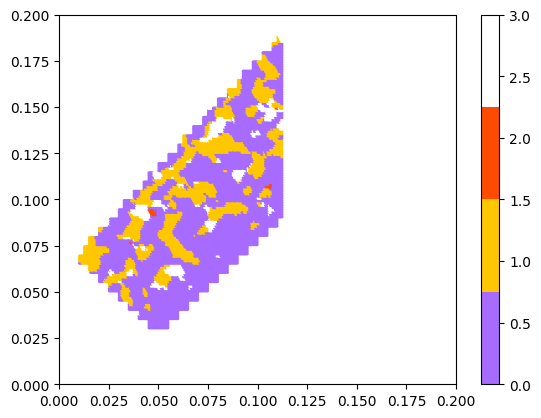

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.371656062140512e-10
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.3344784078876496e-10
step 1/1
step 1/1
epoch 1 Loss 1.34E+00 J -2.14E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.771297466855546e-10
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.581215196629386e-09
step 1/1
step 1/1
epoch 2 Loss 3.96E-01 J -2.68E-01 vf 0.01


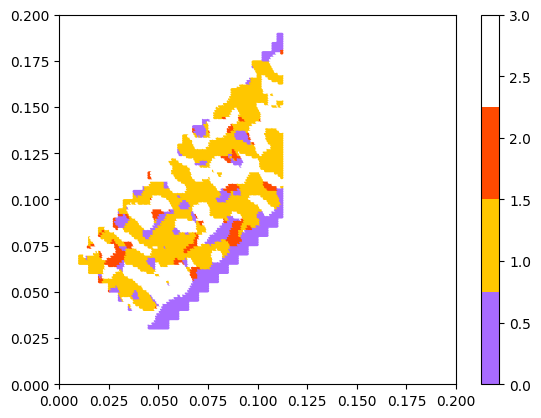

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 9.361926691929247e-12
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 7.551758444749539e-13
step 1/1
step 1/1
epoch 3 Loss -4.03E-01 J -3.21E-01 vf 0.01
step 1/1
NR converged in 18 iters, res_norm/res_norm_0: 5.786686589561226e-12
step 1/1
NR converged in 18 iters, res_norm/res_norm_0: 2.6209420200655833e-08
step 1/1
step 1/1
epoch 4 Loss -1.01E+00 J -3.60E-01 vf 0.01


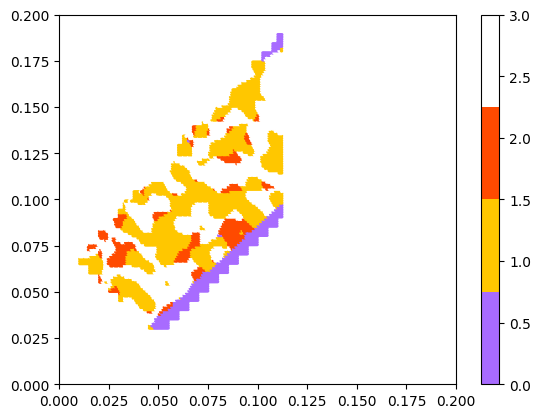

step 1/1
NR converged in 31 iters, res_norm/res_norm_0: 4.207398208796102e-08
step 1/1
NR converged in 33 iters, res_norm/res_norm_0: 4.046470003639757e-12
step 1/1
step 1/1
epoch 5 Loss -1.49E+00 J -3.89E-01 vf 0.01
step 1/1
NR converged in 43 iters, res_norm/res_norm_0: 2.0823397812515135e-08
step 1/1
NR converged in 49 iters, res_norm/res_norm_0: 3.9078714211099773e-10
step 1/1
step 1/1
epoch 6 Loss -1.82E+00 J -4.02E-01 vf 0.01


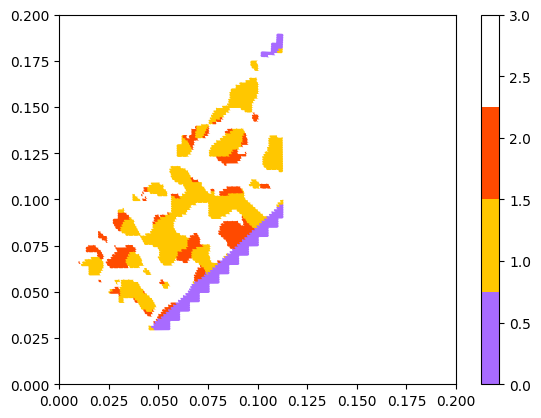

step 1/1
NR converged in 35 iters, res_norm/res_norm_0: 9.271349350799676e-09
step 1/1
NR converged in 37 iters, res_norm/res_norm_0: 4.6554745299914035e-09
step 1/1
step 1/1
epoch 7 Loss -2.02E+00 J -4.10E-01 vf 0.01
step 1/1
NR converged in 49 iters, res_norm/res_norm_0: 2.091626229560806e-08
step 1/1
NR converged in 39 iters, res_norm/res_norm_0: 1.8005312151203435e-09
step 1/1
step 1/1
epoch 8 Loss -2.15E+00 J -4.18E-01 vf 0.01


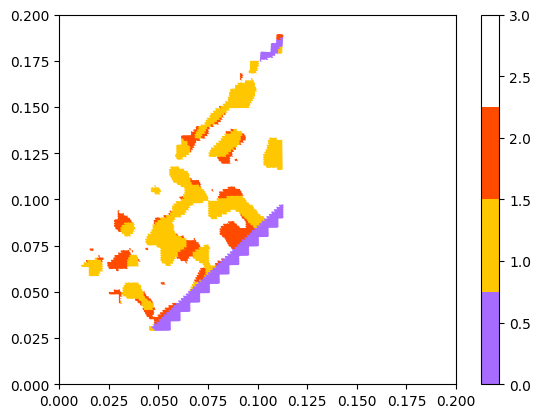

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 2.6791050162254496e-11
step 1/1
NR converged in 13 iters, res_norm/res_norm_0: 8.431781365682916e-08
step 1/1
step 1/1
epoch 9 Loss -2.21E+00 J -4.18E-01 vf 0.01
step 1/1
NR converged in 37 iters, res_norm/res_norm_0: 1.929341246235402e-08
step 1/1
NR converged in 42 iters, res_norm/res_norm_0: 1.6392561703644605e-08
step 1/1
step 1/1
epoch 10 Loss -2.29E+00 J -4.25E-01 vf 0.01


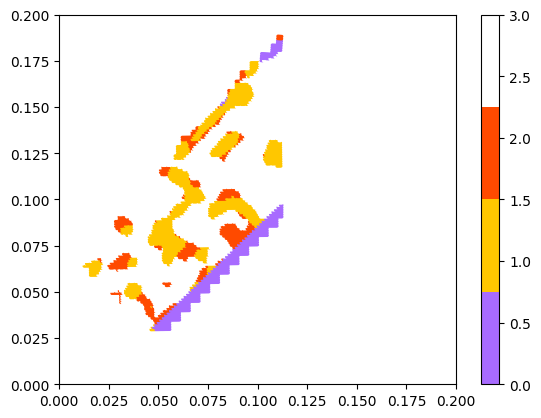

step 1/1
NR converged in 49 iters, res_norm/res_norm_0: 1.5419086795100477e-09
step 1/1
NR converged in 58 iters, res_norm/res_norm_0: 5.566373256386375e-11
step 1/1
step 1/1
epoch 11 Loss -7.31E-01 J -4.28E-01 vf 0.01
step 1/1
NR converged in 14 iters, res_norm/res_norm_0: 7.74677280639745e-11
step 1/1
NR stopped in 60 iters, res_norm/res_norm_0: 8.720748774177398e-05
step 1/1
step 1/1
epoch 12 Loss -7.64E-01 J -4.30E-01 vf 0.01


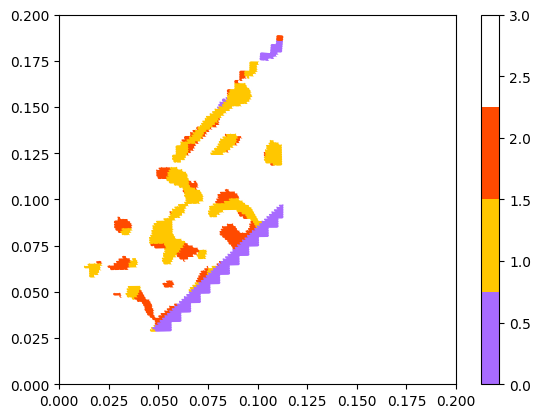

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 2.79199511659936e-11
step 1/1
NR converged in 52 iters, res_norm/res_norm_0: 5.960702810945185e-08
step 1/1
step 1/1
epoch 13 Loss -7.80E-01 J -4.27E-01 vf 0.01
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 9.15776953932936e-09
step 1/1
NR converged in 58 iters, res_norm/res_norm_0: 9.09819670924427e-10
step 1/1
step 1/1
epoch 14 Loss -7.97E-01 J -4.25E-01 vf 0.01


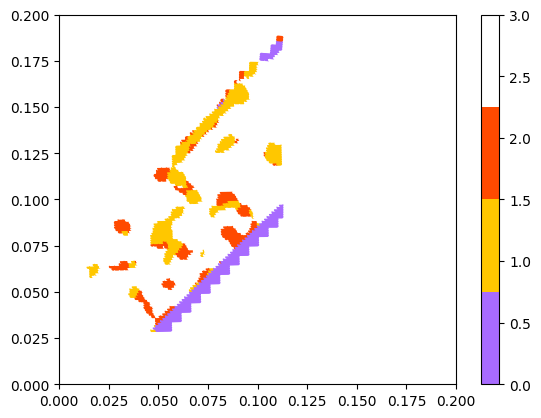

step 1/1
NR converged in 14 iters, res_norm/res_norm_0: 1.1102955370928203e-10
step 1/1
NR converged in 42 iters, res_norm/res_norm_0: 5.412582606343073e-11
step 1/1
step 1/1
epoch 15 Loss -8.09E-01 J -4.23E-01 vf 0.01
step 1/1
NR converged in 24 iters, res_norm/res_norm_0: 1.706930687291425e-09
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 2.8719279268935193e-10
step 1/1
step 1/1
epoch 16 Loss -8.18E-01 J -4.20E-01 vf 0.00


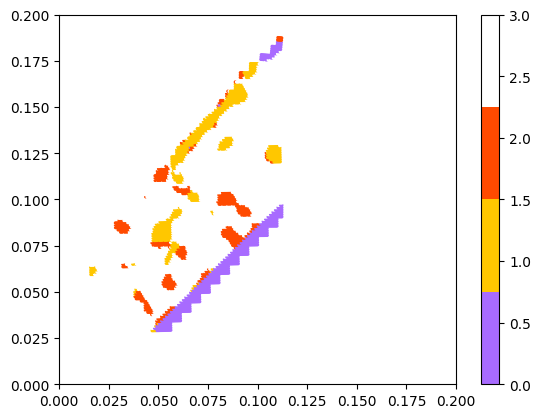

step 1/1
NR converged in 16 iters, res_norm/res_norm_0: 5.729857225763237e-09
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 3.4203594506820856e-10
step 1/1
step 1/1
epoch 17 Loss -8.24E-01 J -4.17E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 6.228667661309802e-08
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 3.7261881711776395e-09
step 1/1
step 1/1
epoch 18 Loss -8.30E-01 J -4.16E-01 vf 0.00


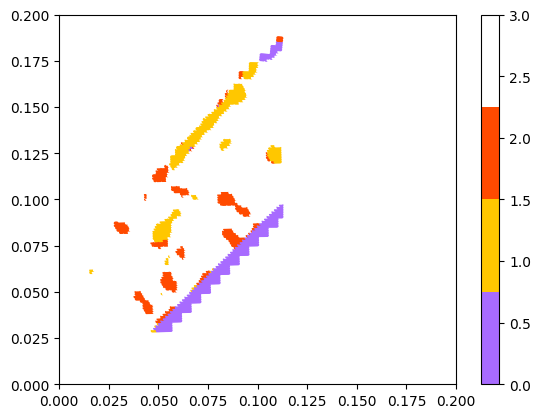

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 5.738967339966817e-11
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 2.5740984631973957e-12
step 1/1
step 1/1
epoch 19 Loss -8.36E-01 J -4.15E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 4.879163942161314e-10
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 9.171408383547406e-11
step 1/1
step 1/1
epoch 20 Loss -8.43E-01 J -4.16E-01 vf 0.00


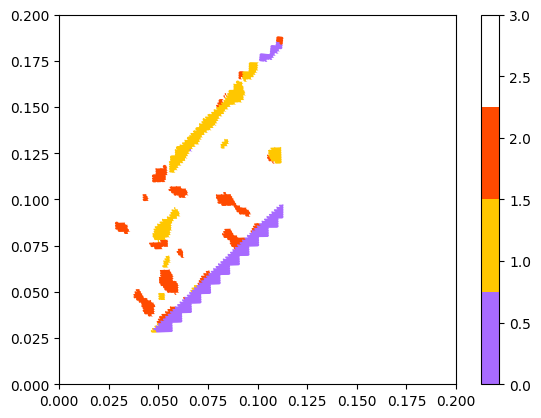

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 2.5187654596768975e-09
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 4.474350085203196e-11
step 1/1
step 1/1
epoch 21 Loss -8.51E-01 J -4.18E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 4.06482378254589e-08
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 4.6441972433370894e-11
step 1/1
step 1/1
epoch 22 Loss -8.60E-01 J -4.21E-01 vf 0.00


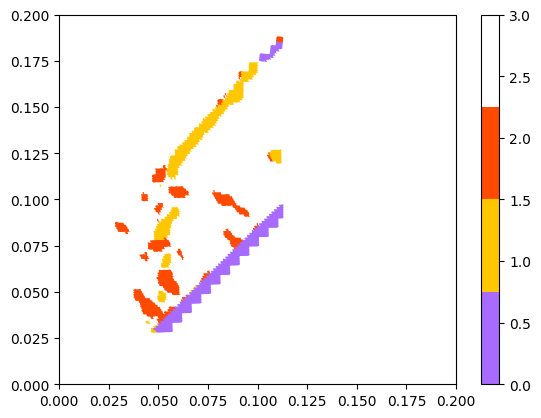

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 7.864814294316758e-08
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.1702826855480108e-11
step 1/1
step 1/1
epoch 23 Loss -8.70E-01 J -4.24E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 4.6326542583004596e-11
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 5.547645078503517e-12
step 1/1
step 1/1
epoch 24 Loss -8.79E-01 J -4.28E-01 vf 0.00


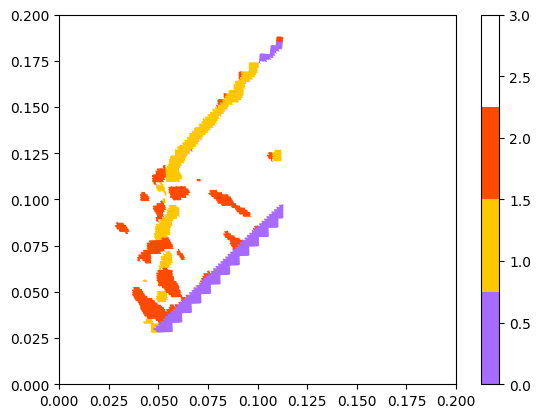

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 8.576554104288846e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 5.935241885613895e-11
step 1/1
step 1/1
epoch 25 Loss -8.88E-01 J -4.32E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 2.936803500221775e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.1763522794582516e-08
step 1/1
step 1/1
epoch 26 Loss -8.97E-01 J -4.35E-01 vf 0.00


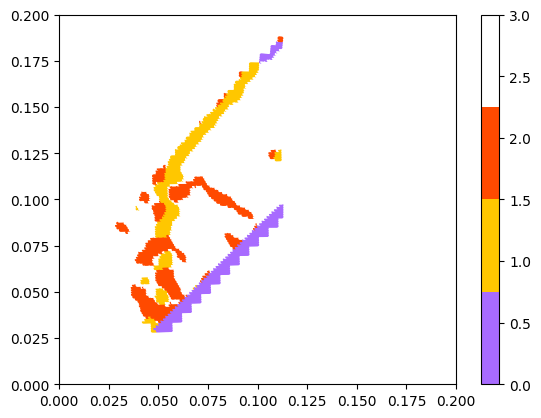

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 3.5777127882087448e-09
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 2.1947678494091896e-09
step 1/1
step 1/1
epoch 27 Loss -9.04E-01 J -4.38E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.4498414424407563e-10
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.4679732064907286e-09
step 1/1
step 1/1
epoch 28 Loss -9.11E-01 J -4.40E-01 vf 0.00


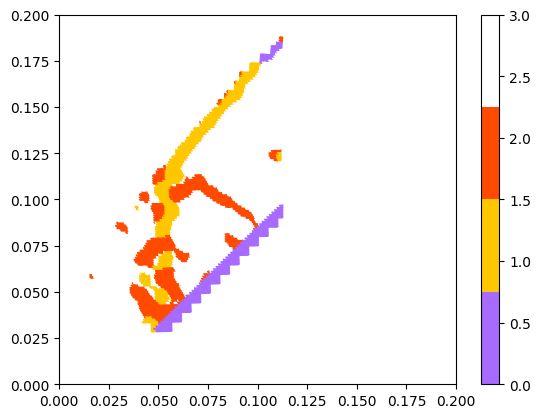

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.3585366015064812e-08
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.208145401989698e-09
step 1/1
step 1/1
epoch 29 Loss -9.17E-01 J -4.42E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 9.092854539764962e-09
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 2.3290914997426487e-09
step 1/1
step 1/1
epoch 30 Loss -9.22E-01 J -4.44E-01 vf 0.00


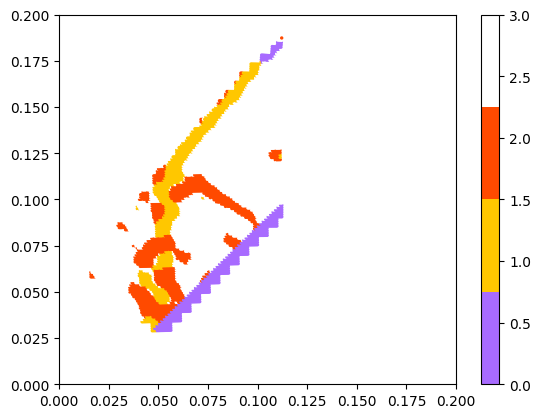

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 6.8619951037501455e-09
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.9085215177483222e-09
step 1/1
step 1/1
epoch 31 Loss -9.27E-01 J -4.46E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 6.302999695663952e-09
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 3.3203520639188274e-09
step 1/1
step 1/1
epoch 32 Loss -9.32E-01 J -4.47E-01 vf 0.00


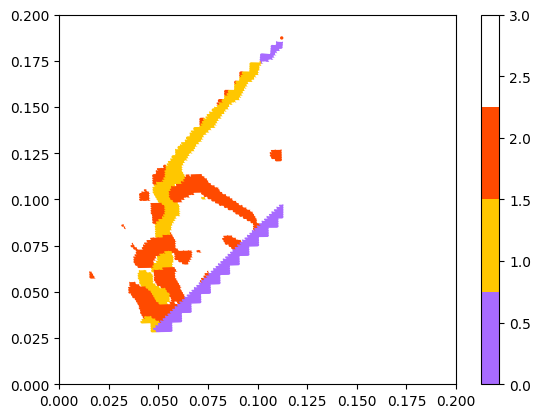

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.1657372690961372e-10
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 3.9975980502954576e-11
step 1/1
step 1/1
epoch 33 Loss -9.37E-01 J -4.48E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.1777645903172887e-09
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 4.23582979350906e-09
step 1/1
step 1/1
epoch 34 Loss -9.41E-01 J -4.49E-01 vf 0.00


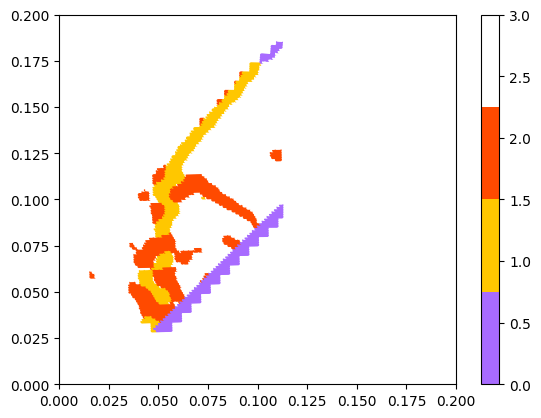

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 4.256220302150799e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.2645579204703485e-09
step 1/1
step 1/1
epoch 35 Loss -9.45E-01 J -4.49E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 1.5964555060347017e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.1288241621301542e-09
step 1/1
step 1/1
epoch 36 Loss -9.49E-01 J -4.50E-01 vf 0.00


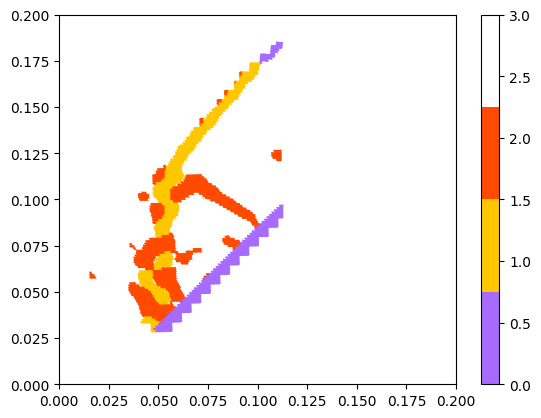

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 1.7559458222930797e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.1134284892960695e-08
step 1/1
step 1/1
epoch 37 Loss -9.53E-01 J -4.50E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 5.6786470524795476e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.216798175360359e-10
step 1/1
step 1/1
epoch 38 Loss -9.56E-01 J -4.51E-01 vf 0.00


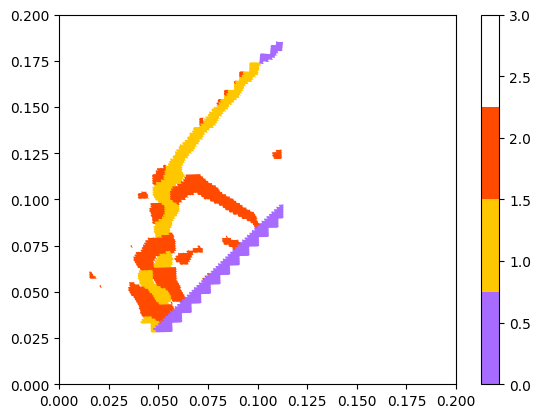

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.244125295506266e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.77740562290209e-09
step 1/1
step 1/1
epoch 39 Loss -9.60E-01 J -4.51E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.954699452559726e-09
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 2.658854584309713e-10
step 1/1
step 1/1
epoch 40 Loss -9.63E-01 J -4.52E-01 vf 0.00


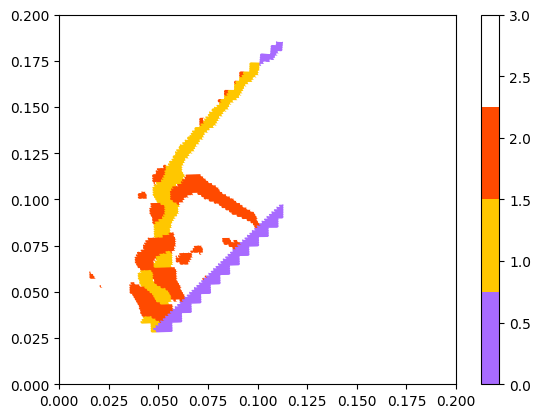

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.216974271892051e-09
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 4.110202920699384e-09
step 1/1
step 1/1
epoch 41 Loss -9.67E-01 J -4.52E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.8804843692014024e-09
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 4.7114759230167354e-08
step 1/1
step 1/1
epoch 42 Loss -9.70E-01 J -4.52E-01 vf 0.00


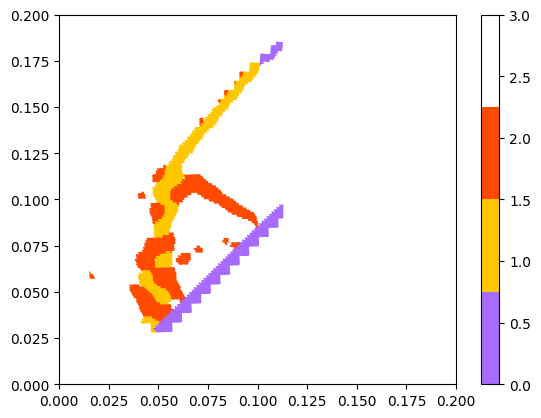

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.1610347214734533e-11
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 5.0822751098352365e-08
step 1/1
step 1/1
epoch 43 Loss -9.73E-01 J -4.52E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.2166225174959002e-10
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.6725047474408537e-08
step 1/1
step 1/1
epoch 44 Loss -9.76E-01 J -4.53E-01 vf 0.00


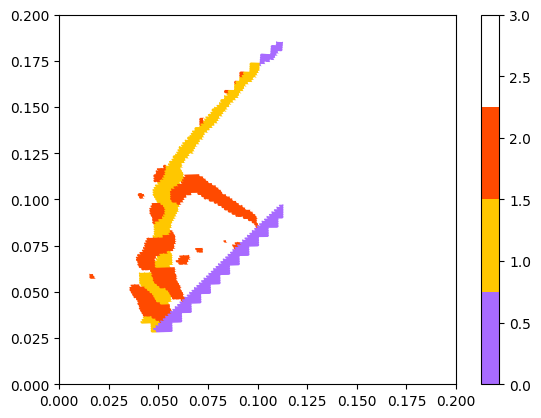

step 1/1
NR converged in 13 iters, res_norm/res_norm_0: 2.7199669722718358e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.2814357271162915e-08
step 1/1
step 1/1
epoch 45 Loss -9.78E-01 J -4.53E-01 vf 0.00
step 1/1
NR converged in 17 iters, res_norm/res_norm_0: 1.8314014516233885e-10
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.997595357822249e-08
step 1/1
step 1/1
epoch 46 Loss -9.81E-01 J -4.53E-01 vf 0.00


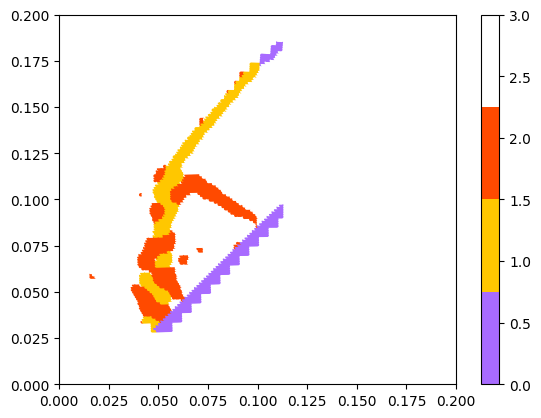

step 1/1
NR converged in 17 iters, res_norm/res_norm_0: 9.205298889345311e-09
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 3.693147708371732e-08
step 1/1
step 1/1
epoch 47 Loss -9.83E-01 J -4.53E-01 vf 0.00
step 1/1
NR converged in 17 iters, res_norm/res_norm_0: 1.1328509802449574e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 4.856841588483752e-08
step 1/1
step 1/1
epoch 48 Loss -9.85E-01 J -4.53E-01 vf 0.00


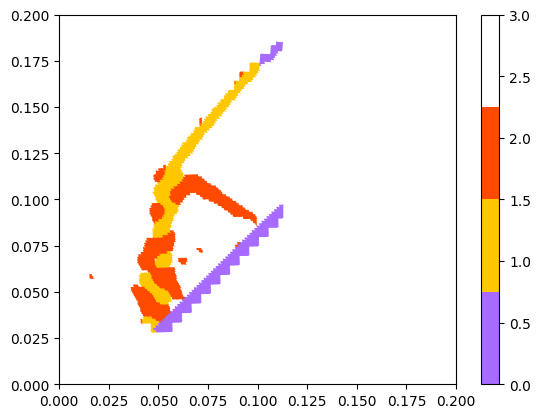

step 1/1
NR converged in 13 iters, res_norm/res_norm_0: 5.999021131812497e-10
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 3.676197844044735e-08
step 1/1
step 1/1
epoch 49 Loss -9.87E-01 J -4.53E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.653052600694282e-12
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.1279061088681768e-08
step 1/1
step 1/1
epoch 50 Loss -9.89E-01 J -4.53E-01 vf 0.00


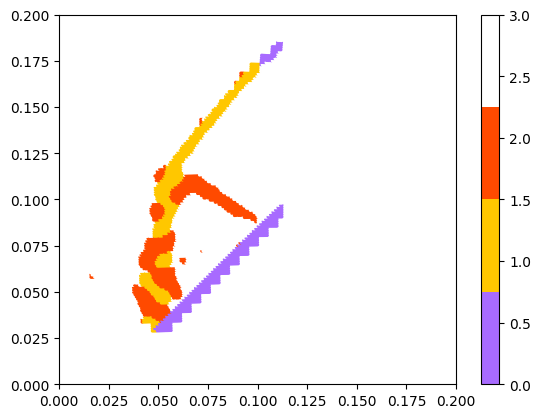

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.521012685385416e-09
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 6.716548436980431e-10
step 1/1
step 1/1
epoch 51 Loss -9.91E-01 J -4.53E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.2972670840546282e-10
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.9659143172791405e-10
step 1/1
step 1/1
epoch 52 Loss -9.93E-01 J -4.53E-01 vf 0.00


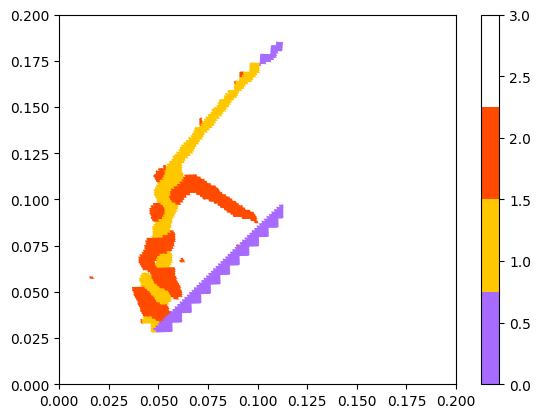

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.6855257197840404e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 6.863565553067967e-11
step 1/1
step 1/1
epoch 53 Loss -9.95E-01 J -4.54E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.112219406606396e-09
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 5.193231356095184e-11
step 1/1
step 1/1
epoch 54 Loss -9.97E-01 J -4.54E-01 vf 0.00


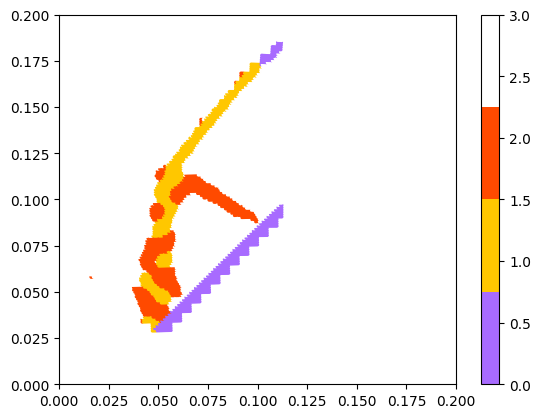

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.26653818468573e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 7.015860582294941e-11
step 1/1
step 1/1
epoch 55 Loss -9.99E-01 J -4.54E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.874801350009848e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.1356035886363875e-10
step 1/1
step 1/1
epoch 56 Loss -1.00E+00 J -4.54E-01 vf 0.00


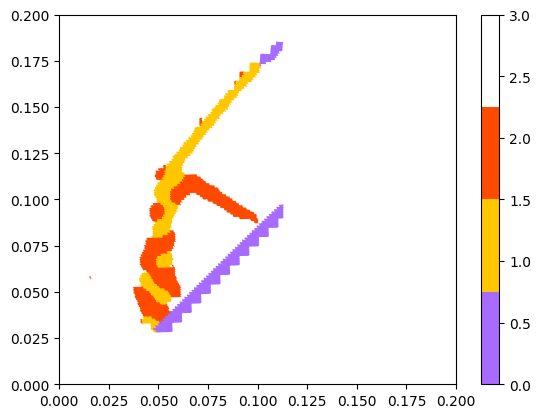

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.858864782957521e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.6261922926930213e-10
step 1/1
step 1/1
epoch 57 Loss -1.00E+00 J -4.54E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.051106296168781e-08
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 5.876561199289842e-11
step 1/1
step 1/1
epoch 58 Loss -1.00E+00 J -4.54E-01 vf 0.00


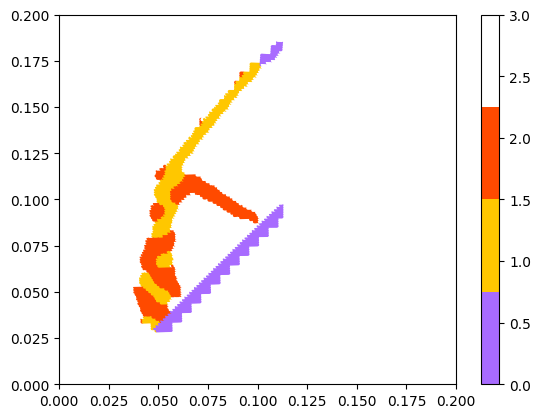

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.361906143111021e-08
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 4.970815470830417e-08
step 1/1
step 1/1
epoch 59 Loss -1.01E+00 J -4.54E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.9291995918438855e-09
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 8.499775123072949e-10
step 1/1
step 1/1
epoch 60 Loss -1.01E+00 J -4.55E-01 vf 0.00


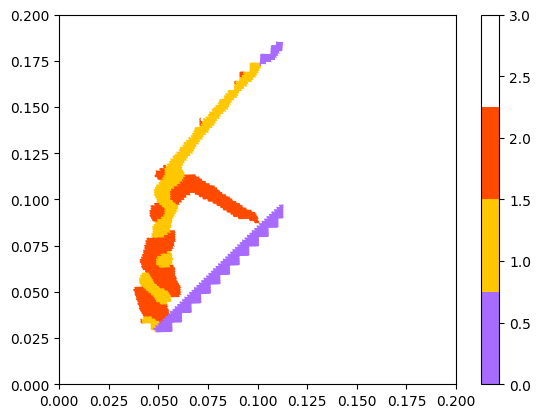

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.204152892392763e-09
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 5.051793961841195e-08
step 1/1
step 1/1
epoch 61 Loss -1.01E+00 J -4.55E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.725495067631638e-09
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 7.939173201298329e-11
step 1/1
step 1/1
epoch 62 Loss -1.01E+00 J -4.55E-01 vf 0.00


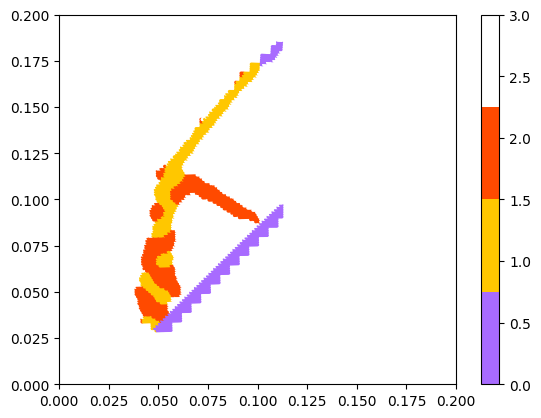

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.365340792280708e-09
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.090723252107391e-09
step 1/1
step 1/1
epoch 63 Loss -1.01E+00 J -4.55E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.027046850892188e-08
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.021531687904089e-10
step 1/1
step 1/1
epoch 64 Loss -1.01E+00 J -4.55E-01 vf 0.00


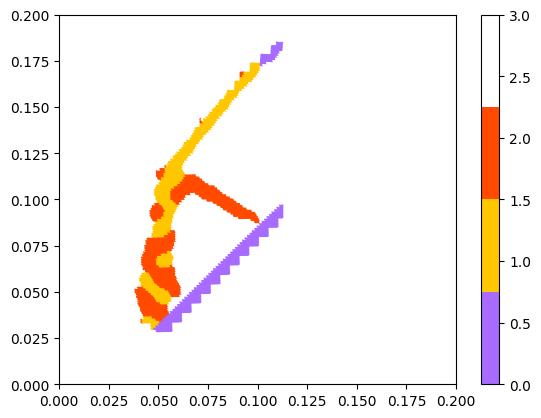

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.9667018858168363e-11
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.2446530491156997e-11
step 1/1
step 1/1
epoch 65 Loss -1.01E+00 J -4.55E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.1018916610756416e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.247858081816921e-08
step 1/1
step 1/1
epoch 66 Loss -1.02E+00 J -4.55E-01 vf 0.00


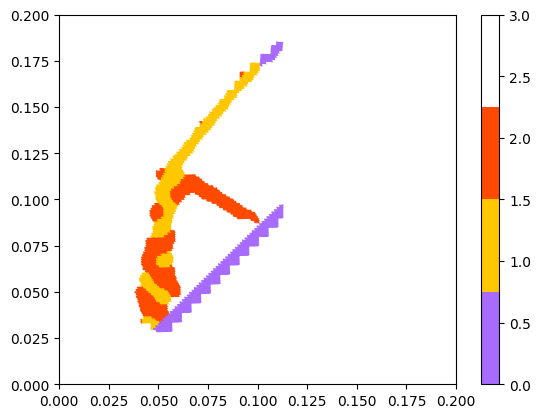

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.8613474888275135e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.800563285859353e-08
step 1/1
step 1/1
epoch 67 Loss -1.02E+00 J -4.55E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 8.94009476667703e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2548342027502456e-08
step 1/1
step 1/1
epoch 68 Loss -1.02E+00 J -4.55E-01 vf 0.00


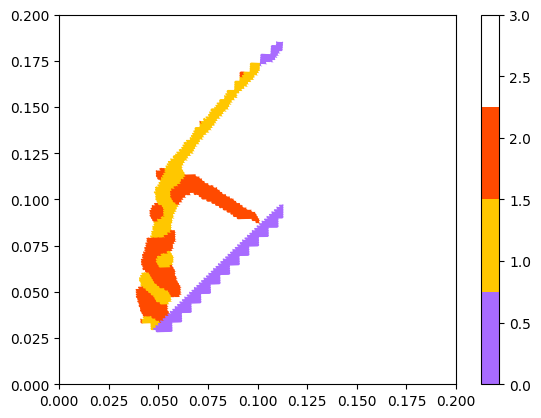

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 2.2271962750182185e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.290918941398845e-09
step 1/1
step 1/1
epoch 69 Loss -1.02E+00 J -4.56E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.529122332960418e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.155937637120042e-09
step 1/1
step 1/1
epoch 70 Loss -1.02E+00 J -4.56E-01 vf 0.00


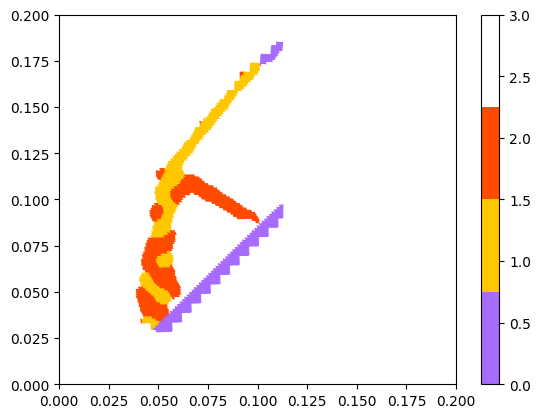

step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 2.767628774797986e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.125542231041552e-09
step 1/1
step 1/1
epoch 71 Loss -1.02E+00 J -4.56E-01 vf 0.00
step 1/1
NR converged in 14 iters, res_norm/res_norm_0: 1.6807981379853046e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.5503613345446275e-09
step 1/1
step 1/1
epoch 72 Loss -1.02E+00 J -4.56E-01 vf 0.00


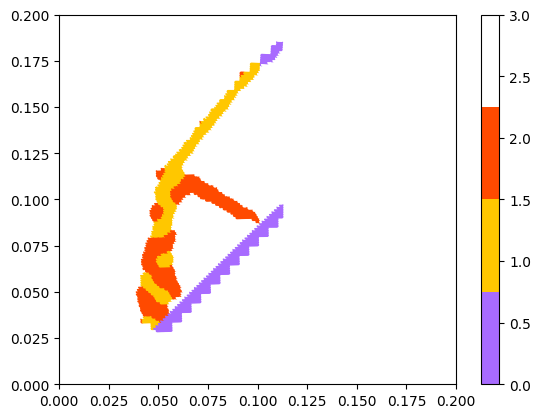

step 1/1
NR converged in 17 iters, res_norm/res_norm_0: 8.017988003054573e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.172347324222928e-09
step 1/1
step 1/1
epoch 73 Loss -1.02E+00 J -4.56E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 2.7105006979045178e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.8761835572959557e-09
step 1/1
step 1/1
epoch 74 Loss -1.03E+00 J -4.56E-01 vf 0.00


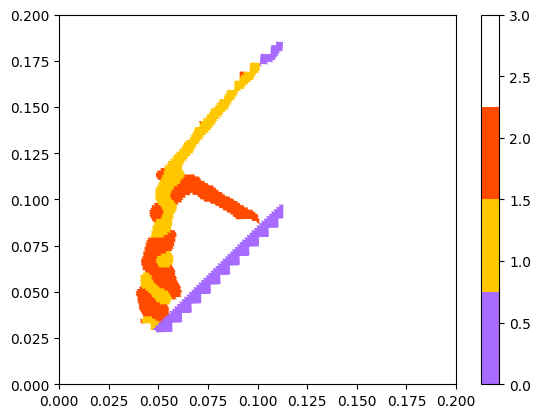

step 1/1
NR converged in 13 iters, res_norm/res_norm_0: 1.2173827548920604e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.6972697338879312e-09
step 1/1
step 1/1
epoch 75 Loss -1.03E+00 J -4.56E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 1.0260463109803476e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.5545114037640462e-09
step 1/1
step 1/1
epoch 76 Loss -1.03E+00 J -4.56E-01 vf 0.00


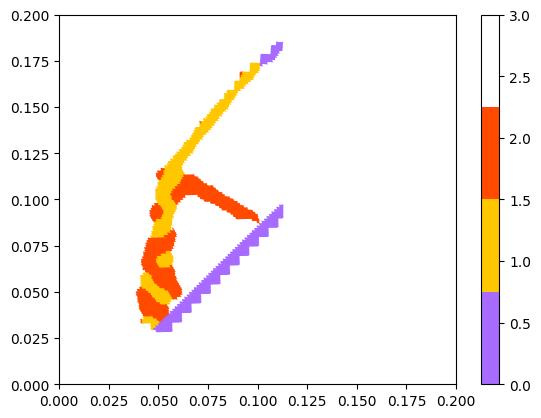

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 5.2816718342821855e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.3794190617366417e-09
step 1/1
step 1/1
epoch 77 Loss -1.03E+00 J -4.56E-01 vf 0.00
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 2.461429111311571e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.200585284870671e-09
step 1/1
step 1/1
epoch 78 Loss -1.03E+00 J -4.56E-01 vf 0.00


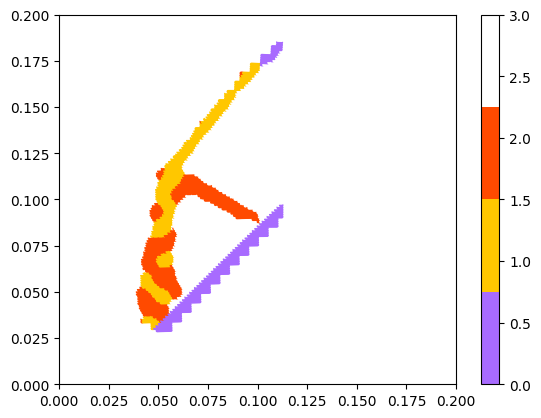

step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 8.877691171936791e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.038402694150445e-09
step 1/1
step 1/1
epoch 79 Loss -1.03E+00 J -4.57E-01 vf 0.00
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.0950424847486298e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.904357907903739e-09
step 1/1
step 1/1
epoch 80 Loss -1.03E+00 J -4.57E-01 vf 0.00


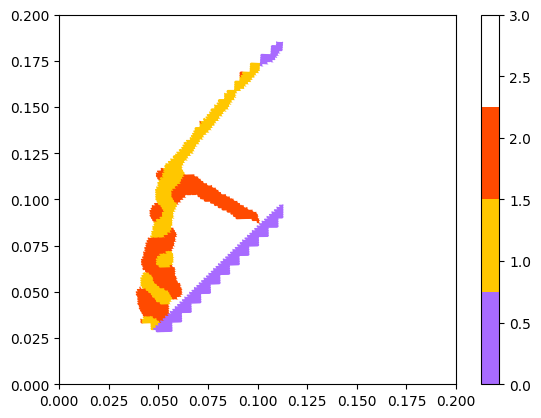

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 7.24586581189592e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.7633777009435023e-09
step 1/1
step 1/1
epoch 81 Loss -1.03E+00 J -4.57E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 2.0439222876239116e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.656960977171815e-09
step 1/1
step 1/1
epoch 82 Loss -1.03E+00 J -4.57E-01 vf 0.00


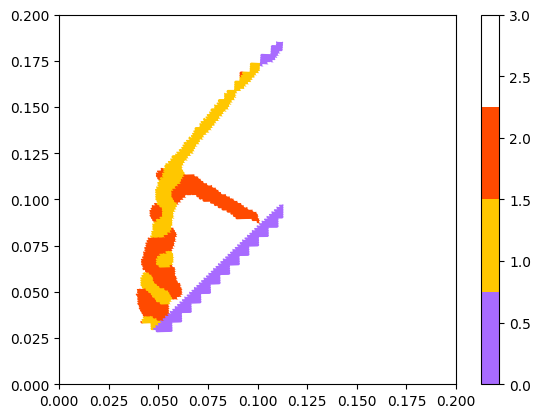

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 7.144653461128653e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5775021685345283e-09
step 1/1
step 1/1
epoch 83 Loss -1.03E+00 J -4.57E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 7.063758358015191e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.522057793856997e-09
step 1/1
step 1/1
epoch 84 Loss -1.04E+00 J -4.57E-01 vf 0.00


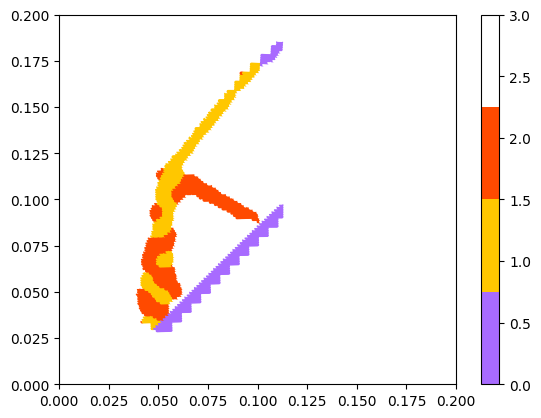

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 5.404303069757644e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.48909697084602e-09
step 1/1
step 1/1
epoch 85 Loss -1.04E+00 J -4.57E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 7.325454836301909e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4702202974190886e-09
step 1/1
step 1/1
epoch 86 Loss -1.04E+00 J -4.57E-01 vf 0.00


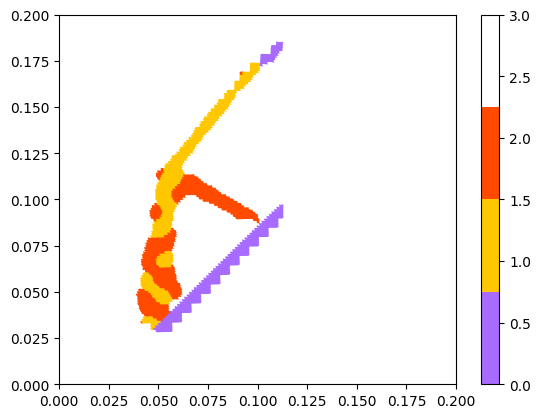

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 4.595214805417135e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4274260070518988e-09
step 1/1
step 1/1
epoch 87 Loss -1.04E+00 J -4.57E-01 vf 0.00
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 8.966038396971394e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.3467389425048004e-09
step 1/1
step 1/1
epoch 88 Loss -1.04E+00 J -4.57E-01 vf 0.00


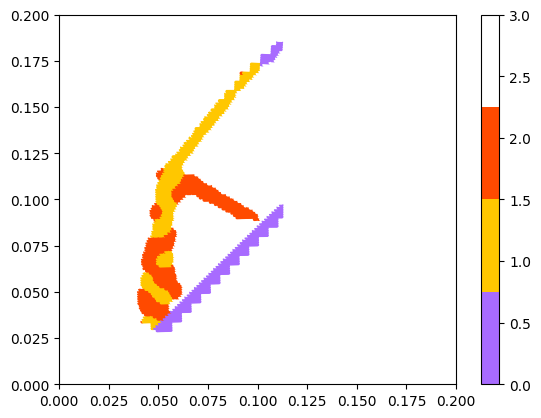

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 5.592247319526744e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2617064842258461e-09
step 1/1
step 1/1
epoch 89 Loss -1.04E+00 J -4.57E-01 vf 0.00
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 3.3846368062469765e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.202067364947297e-09
step 1/1
step 1/1
epoch 90 Loss -1.04E+00 J -4.58E-01 vf 0.00


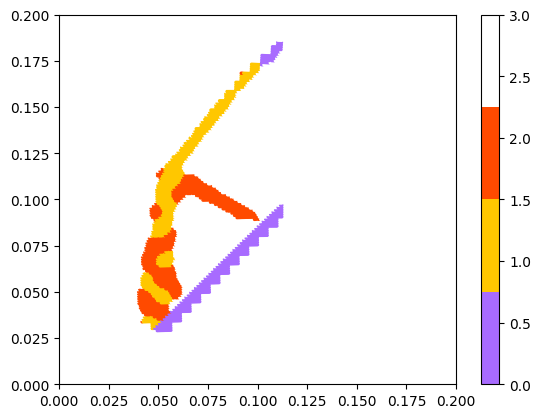

step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 8.131180509993033e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.172672075592661e-09
step 1/1
step 1/1
epoch 91 Loss -1.04E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 4.695648526016403e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.1708932788125566e-09
step 1/1
step 1/1
epoch 92 Loss -1.04E+00 J -4.58E-01 vf 0.00


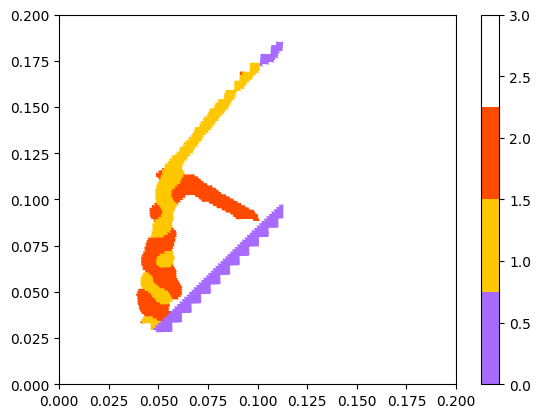

step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 6.743091639193705e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2014906804042794e-09
step 1/1
step 1/1
epoch 93 Loss -1.04E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.9689457901771213e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2364825198226218e-09
step 1/1
step 1/1
epoch 94 Loss -1.04E+00 J -4.58E-01 vf 0.00


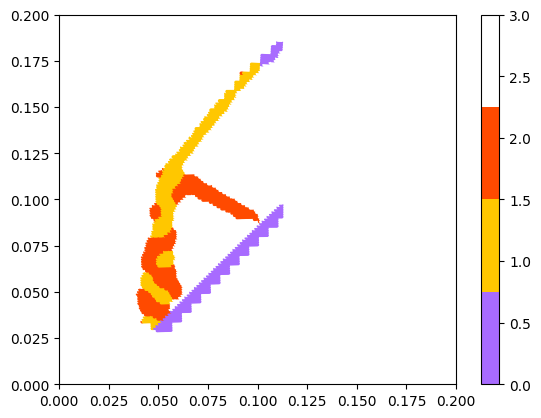

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 2.1775675258190586e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.263468457993503e-09
step 1/1
step 1/1
epoch 95 Loss -1.05E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.0679916137767153e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2743785065976197e-09
step 1/1
step 1/1
epoch 96 Loss -1.05E+00 J -4.58E-01 vf 0.00


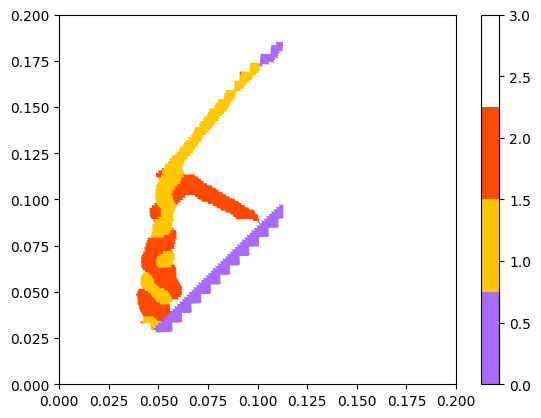

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 9.734764219649436e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2745787161492392e-09
step 1/1
step 1/1
epoch 97 Loss -1.05E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 7.267545471856775e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2775287122336121e-09
step 1/1
step 1/1
epoch 98 Loss -1.05E+00 J -4.58E-01 vf 0.00


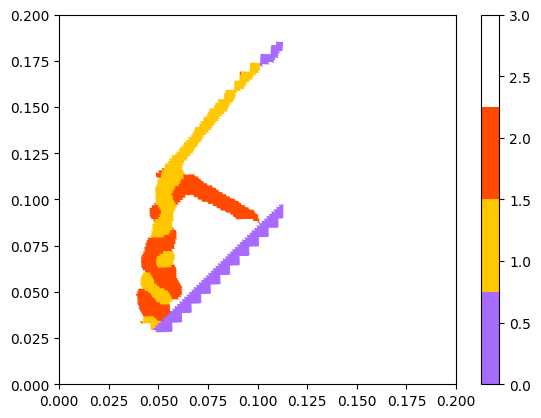

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.735041779280528e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2881047203665722e-09
step 1/1
step 1/1
epoch 99 Loss -1.05E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.066494505829751e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.303399263587694e-09
step 1/1
step 1/1
epoch 100 Loss -1.05E+00 J -4.58E-01 vf 0.00


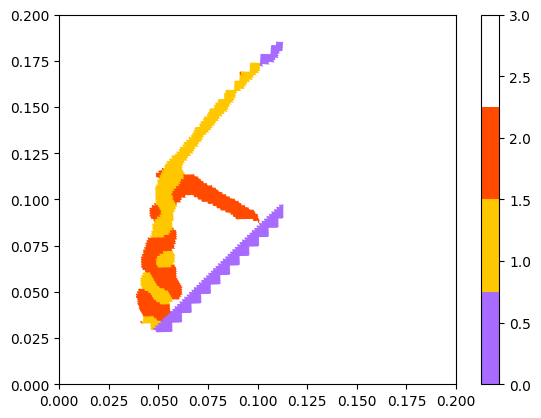

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.126332673723353e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.331853636262407e-09
step 1/1
step 1/1
epoch 101 Loss -1.05E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.476333298337738e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.3663923274082427e-09
step 1/1
step 1/1
epoch 102 Loss -1.05E+00 J -4.58E-01 vf 0.00


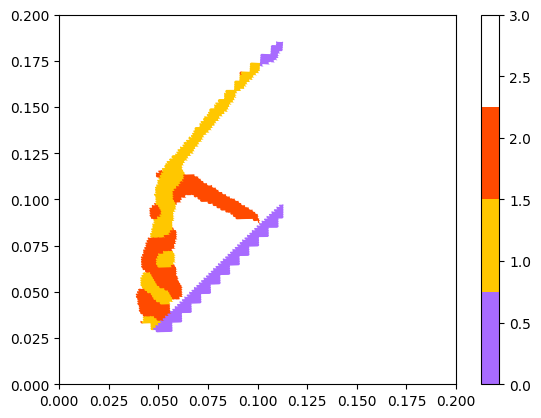

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.67937240810439e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4006216948777781e-09
step 1/1
step 1/1
epoch 103 Loss -1.05E+00 J -4.58E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.393752345820156e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.430546973538723e-09
step 1/1
step 1/1
epoch 104 Loss -1.05E+00 J -4.58E-01 vf 0.00


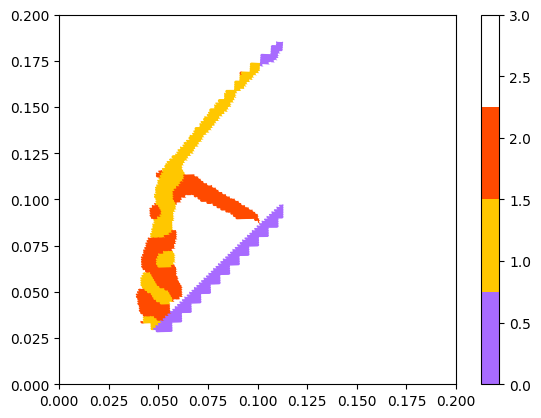

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.5349059543773066e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4577583106998166e-09
step 1/1
step 1/1
epoch 105 Loss -1.05E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 3.4441664203366625e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4891406904408844e-09
step 1/1
step 1/1
epoch 106 Loss -1.05E+00 J -4.59E-01 vf 0.00


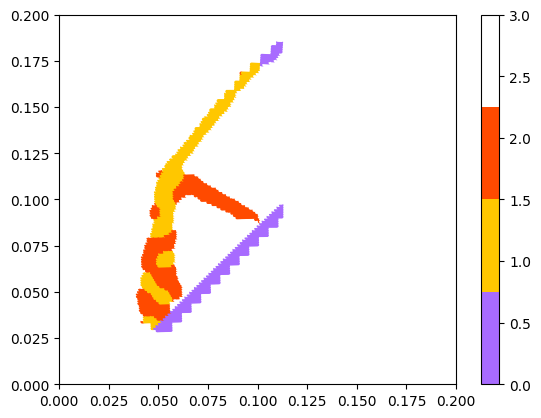

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 2.2358072912465172e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5193789994715981e-09
step 1/1
step 1/1
epoch 107 Loss -1.05E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.2513680077311767e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5407787070048811e-09
step 1/1
step 1/1
epoch 108 Loss -1.05E+00 J -4.59E-01 vf 0.00


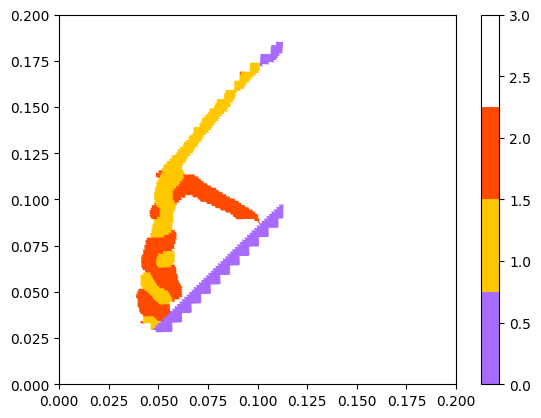

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 5.888011758142369e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5557765823858898e-09
step 1/1
step 1/1
epoch 109 Loss -1.05E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 2.6083653907322928e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5745282422132433e-09
step 1/1
step 1/1
epoch 110 Loss -1.05E+00 J -4.59E-01 vf 0.00


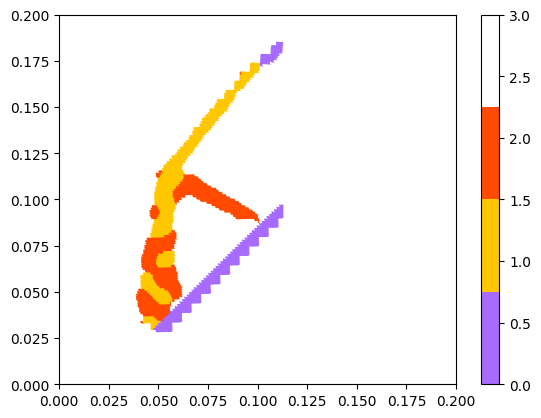

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.0855599753348836e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5933461803622609e-09
step 1/1
step 1/1
epoch 111 Loss -1.06E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 4.35699906115045e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.602160537557087e-09
step 1/1
step 1/1
epoch 112 Loss -1.06E+00 J -4.59E-01 vf 0.00


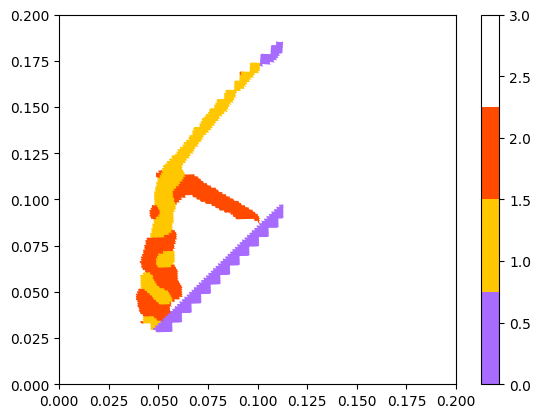

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 1.6814298166857479e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5948334384838962e-09
step 1/1
step 1/1
epoch 113 Loss -1.06E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 6.31141787412094e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.570290163662367e-09
step 1/1
step 1/1
epoch 114 Loss -1.06E+00 J -4.59E-01 vf 0.00


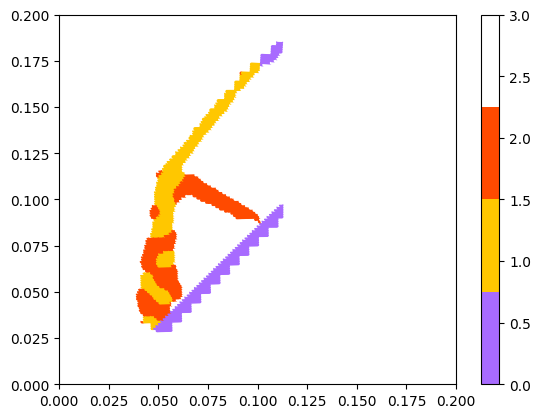

step 1/1
NR converged in 9 iters, res_norm/res_norm_0: 2.273237504417028e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.5283655290739528e-09
step 1/1
step 1/1
epoch 115 Loss -1.06E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.125999793399797e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4689739536890807e-09
step 1/1
step 1/1
epoch 116 Loss -1.06E+00 J -4.59E-01 vf 0.00


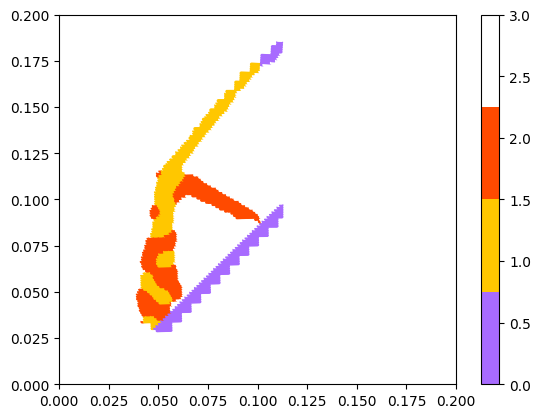

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.351193816487869e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.3975944036544677e-09
step 1/1
step 1/1
epoch 117 Loss -1.06E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.4952972225043876e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.3202552383869044e-09
step 1/1
step 1/1
epoch 118 Loss -1.06E+00 J -4.59E-01 vf 0.00


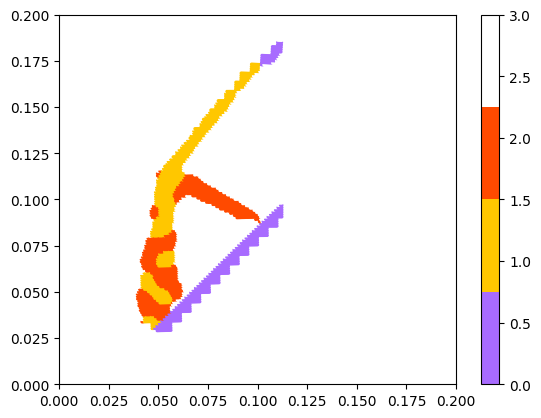

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.245631828614367e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2417061422152914e-09
step 1/1
step 1/1
epoch 119 Loss -1.06E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4194647678169417e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.1646859719914682e-09
step 1/1
step 1/1
epoch 120 Loss -1.06E+00 J -4.59E-01 vf 0.00


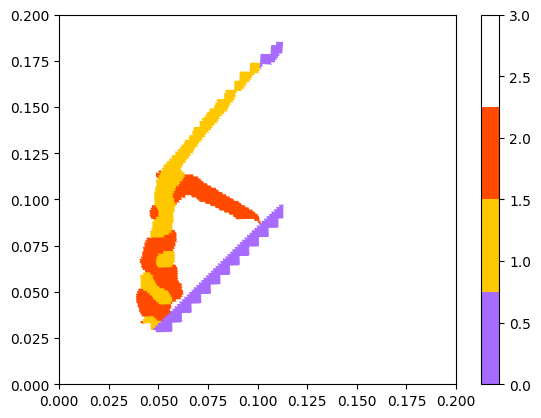

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.64362518598444e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.0834024509405304e-09
step 1/1
step 1/1
epoch 121 Loss -1.06E+00 J -4.59E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.929030193202503e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.9926144703248e-10
step 1/1
step 1/1
epoch 122 Loss -1.06E+00 J -4.59E-01 vf 0.00


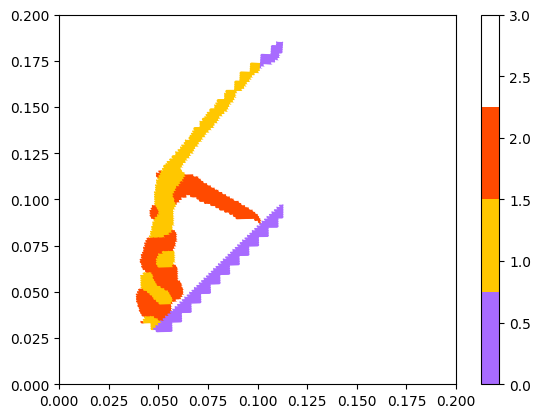

step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.4876642749407794e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.052188647704004e-10
step 1/1
step 1/1
epoch 123 Loss -1.06E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.1480062681662824e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.129164494571097e-10
step 1/1
step 1/1
epoch 124 Loss -1.06E+00 J -4.60E-01 vf 0.00


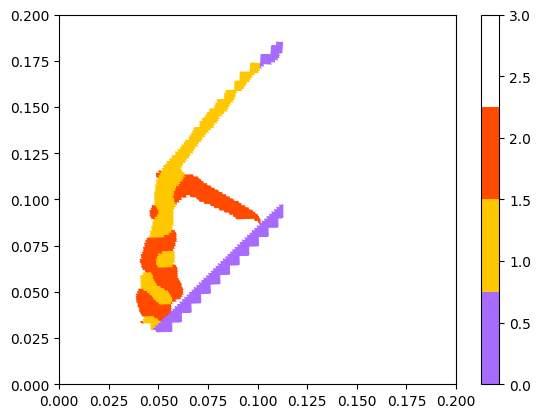

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 9.111766478465881e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.256184915393593e-10
step 1/1
step 1/1
epoch 125 Loss -1.06E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.289127681105464e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.478566737971332e-10
step 1/1
step 1/1
epoch 126 Loss -1.06E+00 J -4.60E-01 vf 0.00


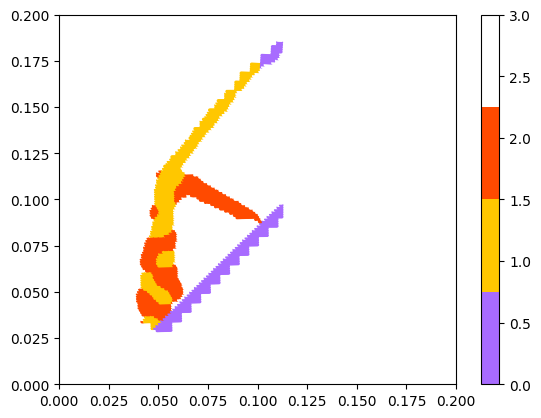

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.08415289180669e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.83118037675187e-10
step 1/1
step 1/1
epoch 127 Loss -1.06E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.8391011830077097e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.313665218486379e-10
step 1/1
step 1/1
epoch 128 Loss -1.06E+00 J -4.60E-01 vf 0.00


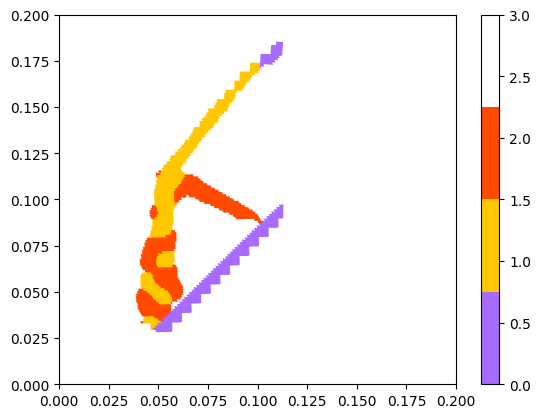

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1143166844247937e-08
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.87313786224372e-10
step 1/1
step 1/1
epoch 129 Loss -1.06E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.8936452140984025e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.506405839979999e-10
step 1/1
step 1/1
epoch 130 Loss -1.07E+00 J -4.60E-01 vf 0.00


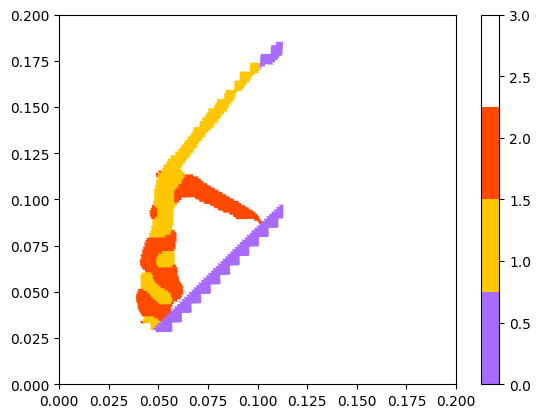

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.408734566233547e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.215246875828766e-10
step 1/1
step 1/1
epoch 131 Loss -1.07E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.902236290332866e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.995287716282632e-10
step 1/1
step 1/1
epoch 132 Loss -1.07E+00 J -4.60E-01 vf 0.00


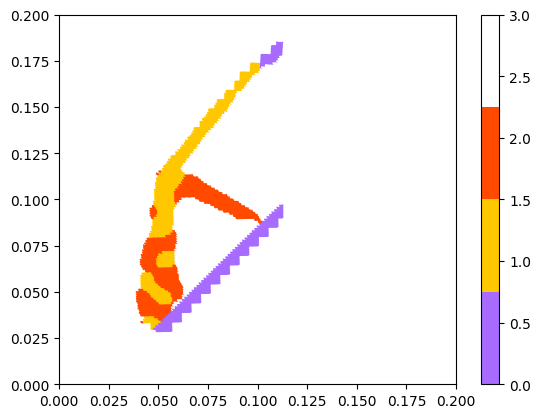

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.966195114471403e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.8048894906318293e-10
step 1/1
step 1/1
epoch 133 Loss -1.07E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.3788452357717153e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.618531083172296e-10
step 1/1
step 1/1
epoch 134 Loss -1.07E+00 J -4.60E-01 vf 0.00


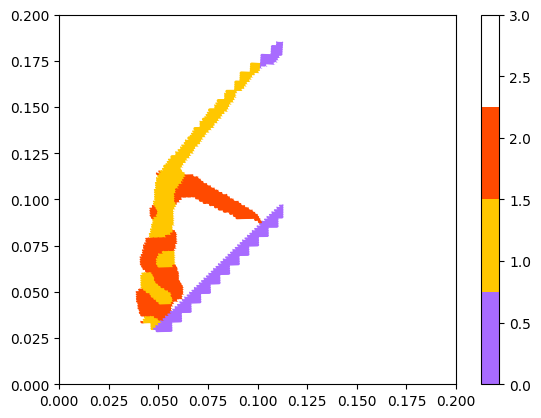

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0103346432404428e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.4036360165662983e-10
step 1/1
step 1/1
epoch 135 Loss -1.07E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.68063409697696e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.1583344019019116e-10
step 1/1
step 1/1
epoch 136 Loss -1.07E+00 J -4.60E-01 vf 0.00


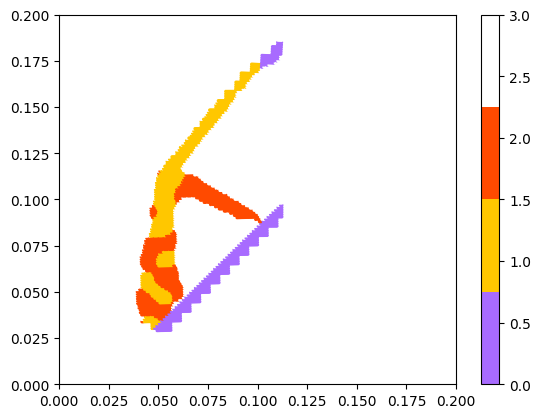

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.847902687446165e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.947648697397146e-10
step 1/1
step 1/1
epoch 137 Loss -1.07E+00 J -4.60E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.3656363162021726e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.8109297903359155e-10
step 1/1
step 1/1
epoch 138 Loss -1.07E+00 J -4.61E-01 vf 0.00


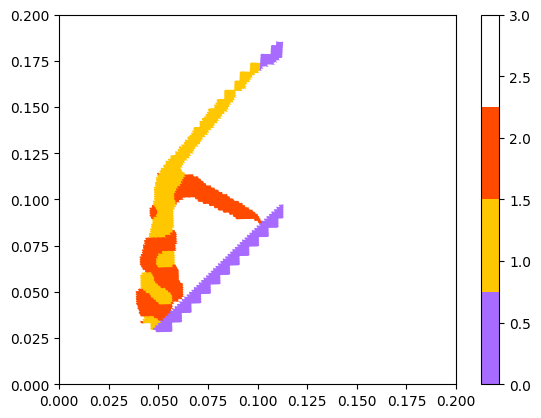

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.1653738764187344e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.7300111009284887e-10
step 1/1
step 1/1
epoch 139 Loss -1.07E+00 J -4.61E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.268977689197467e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.7224003124310715e-10
step 1/1
step 1/1
epoch 140 Loss -1.07E+00 J -4.61E-01 vf 0.00


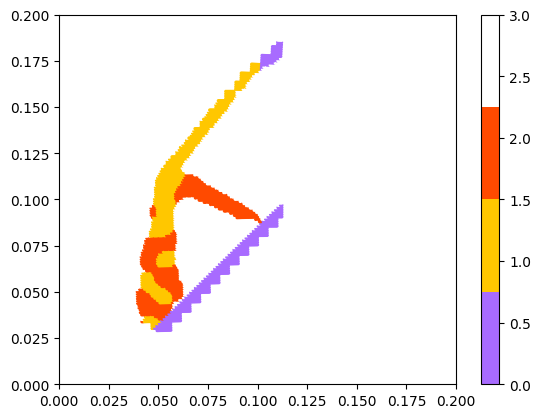

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.617987083188893e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.777853761754143e-10
step 1/1
step 1/1
epoch 141 Loss -1.07E+00 J -4.61E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1582141331634269e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.8797970017498295e-10
step 1/1
step 1/1
epoch 142 Loss -1.07E+00 J -4.61E-01 vf 0.00


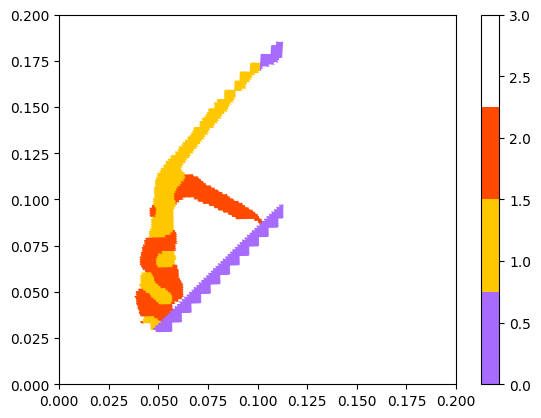

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.328649456660592e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.0122597094812537e-10
step 1/1
step 1/1
epoch 143 Loss -1.07E+00 J -4.61E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.012754452802566e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.164517621200805e-10
step 1/1
step 1/1
epoch 144 Loss -1.07E+00 J -4.61E-01 vf 0.00


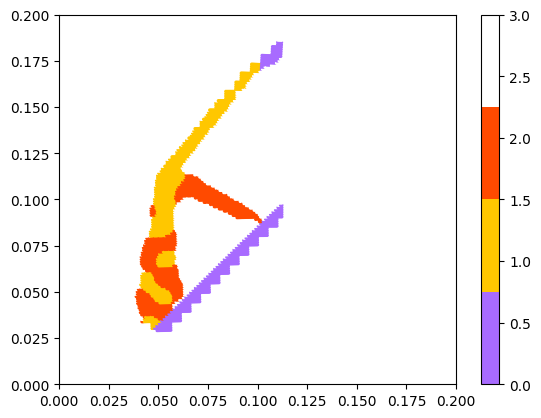

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.379264336398207e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.3503553770803115e-10
step 1/1
step 1/1
epoch 145 Loss -1.07E+00 J -4.61E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.225087053705027e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.593498921092588e-10
step 1/1
step 1/1
epoch 146 Loss -1.07E+00 J -4.61E-01 vf 0.00


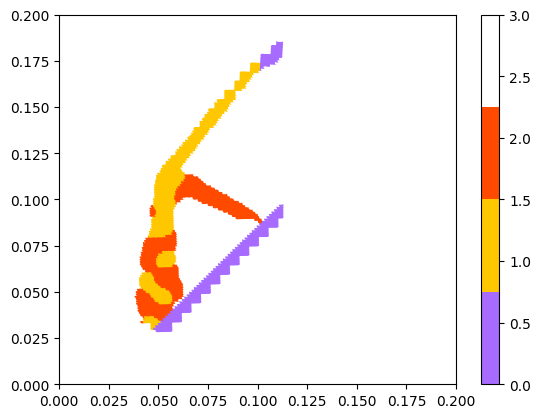

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.394182099577306e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.9353103984956585e-10
step 1/1
step 1/1
epoch 147 Loss -1.07E+00 J -4.61E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.7981273651997382e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.41558267967291e-10
step 1/1
step 1/1
epoch 148 Loss -1.07E+00 J -4.61E-01 vf 0.00


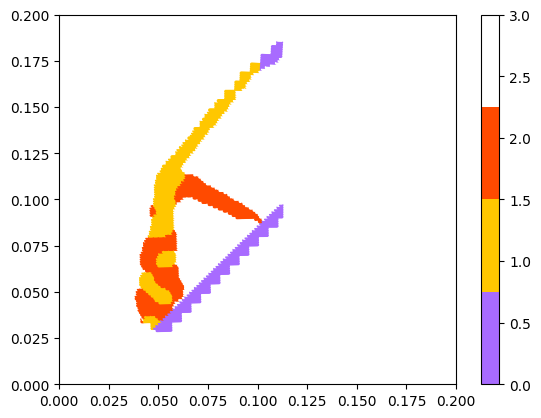

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.3617163351129854e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.071242823709192e-10
step 1/1
step 1/1
epoch 149 Loss -1.07E+00 J -4.61E-01 vf 0.00
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0556350576008808e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.78911391837688e-10
step 1/1
step 1/1
epoch 150 Loss -1.07E+00 J -4.61E-01 vf 0.01


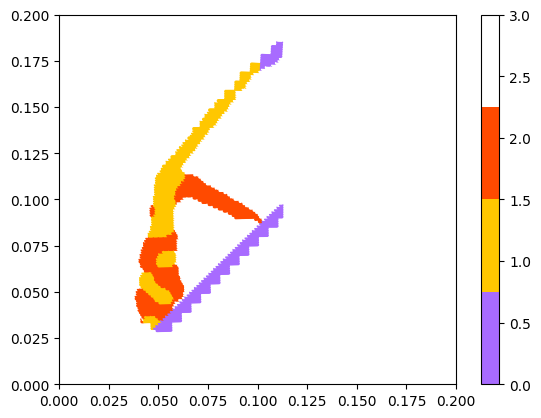

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.4533696720671e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.493515064361556e-10
step 1/1
step 1/1
epoch 151 Loss -1.07E+00 J -4.61E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.003937510713621e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.18535178162912e-10
step 1/1
step 1/1
epoch 152 Loss -1.07E+00 J -4.61E-01 vf 0.01


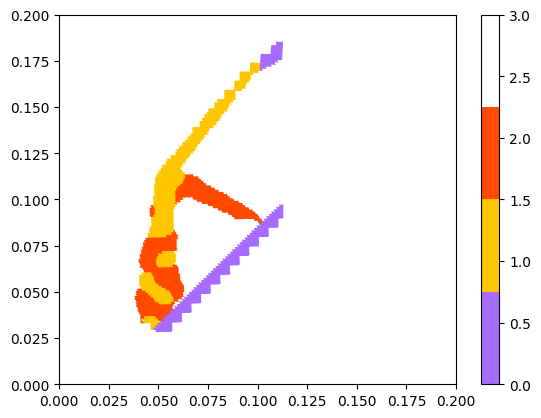

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.957618271559266e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.873039311041068e-10
step 1/1
step 1/1
epoch 153 Loss -1.07E+00 J -4.61E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.094766868439696e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 8.618916355900416e-10
step 1/1
step 1/1
epoch 154 Loss -1.07E+00 J -4.61E-01 vf 0.01


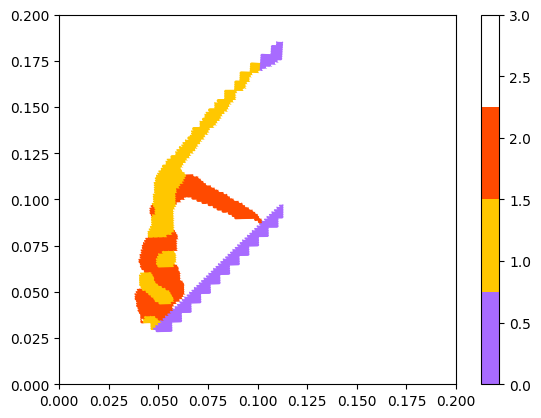

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.305066380143608e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 9.512114587272085e-10
step 1/1
step 1/1
epoch 155 Loss -1.07E+00 J -4.61E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.5692683667398e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.0675439736195915e-09
step 1/1
step 1/1
epoch 156 Loss -1.08E+00 J -4.62E-01 vf 0.01


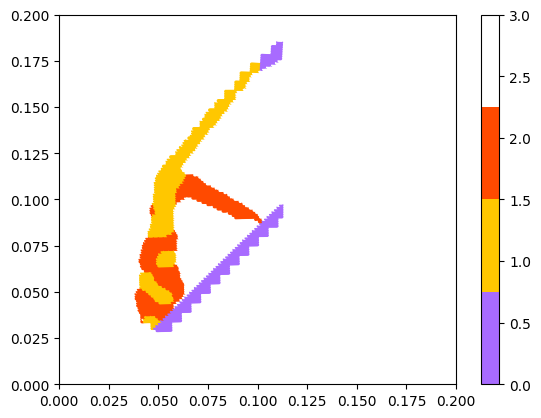

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.868001881177437e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.2301219368023626e-09
step 1/1
step 1/1
epoch 157 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.202251831873975e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.4632925331086838e-09
step 1/1
step 1/1
epoch 158 Loss -1.08E+00 J -4.62E-01 vf 0.01


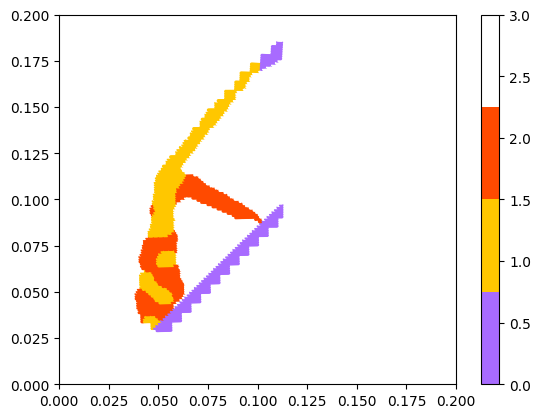

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.611993829234318e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 1.7825821816617569e-09
step 1/1
step 1/1
epoch 159 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.1359509154172826e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.1620541223056338e-09
step 1/1
step 1/1
epoch 160 Loss -1.08E+00 J -4.62E-01 vf 0.01


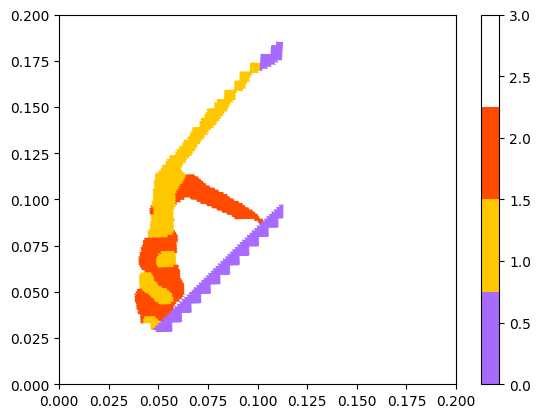

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.080640861978399e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.5434421713441805e-09
step 1/1
step 1/1
epoch 161 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.179397257550457e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.8261941442006204e-09
step 1/1
step 1/1
epoch 162 Loss -1.08E+00 J -4.62E-01 vf 0.01


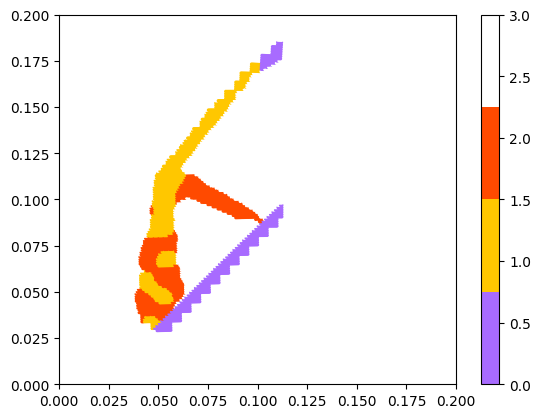

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.06964122027411e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.963441167544855e-09
step 1/1
step 1/1
epoch 163 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.478674560307151e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.962905939916043e-09
step 1/1
step 1/1
epoch 164 Loss -1.08E+00 J -4.62E-01 vf 0.01


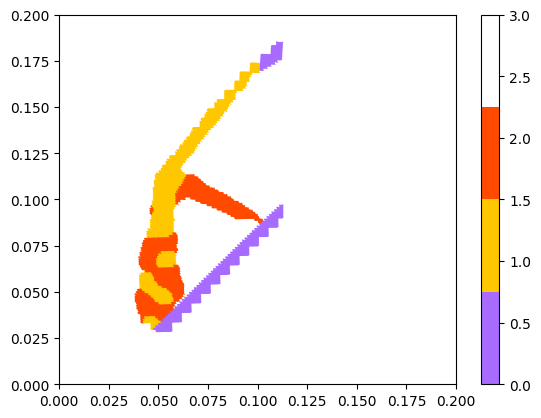

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.387537846280036e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.862642464197936e-09
step 1/1
step 1/1
epoch 165 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 8.584846589257626e-13
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.7235257202564574e-09
step 1/1
step 1/1
epoch 166 Loss -1.08E+00 J -4.62E-01 vf 0.01


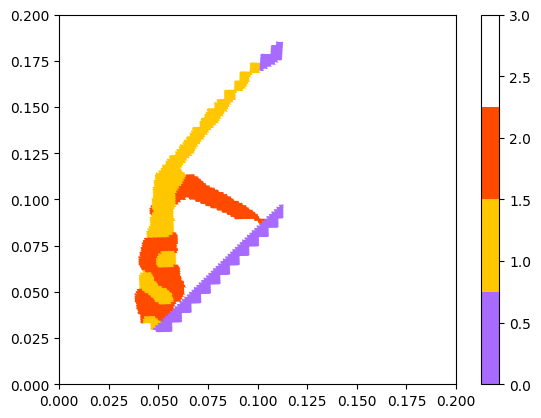

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.7013652194286416e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.602033644143694e-09
step 1/1
step 1/1
epoch 167 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 7.575455137538773e-12
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.5442802900869326e-09
step 1/1
step 1/1
epoch 168 Loss -1.08E+00 J -4.62E-01 vf 0.01


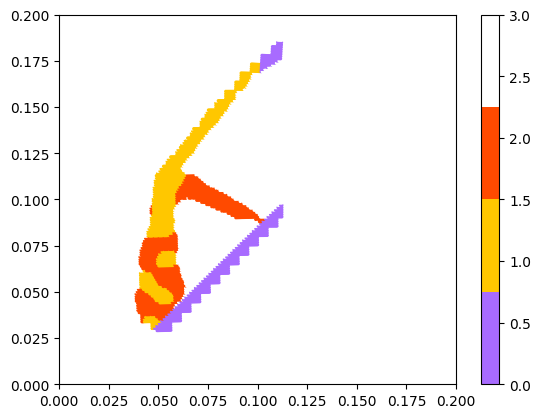

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.915345405908026e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.5787330888881334e-09
step 1/1
step 1/1
epoch 169 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.595327376078376e-11
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.7177936004547693e-09
step 1/1
step 1/1
epoch 170 Loss -1.08E+00 J -4.62E-01 vf 0.01


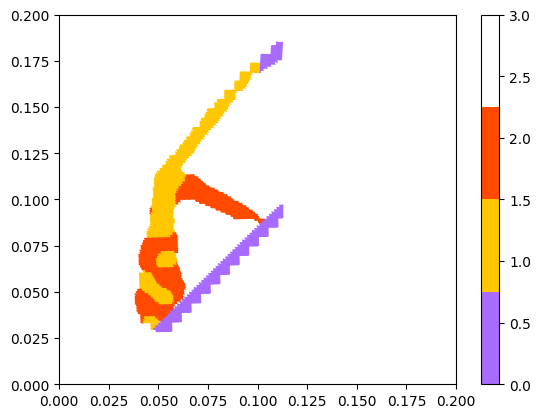

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0462578892944178e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 2.9826707451281492e-09
step 1/1
step 1/1
epoch 171 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.1759593132089553e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.3434920020465683e-09
step 1/1
step 1/1
epoch 172 Loss -1.08E+00 J -4.62E-01 vf 0.01


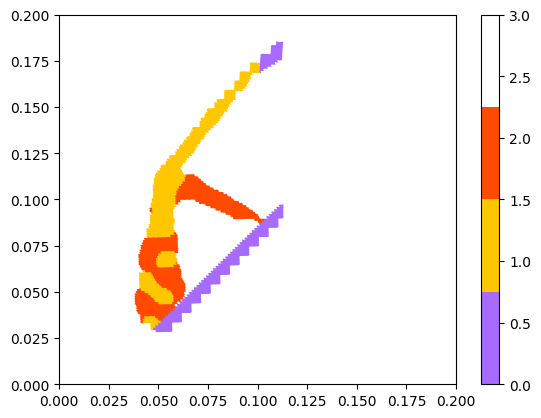

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.0764015203745074e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 3.804527517703633e-09
step 1/1
step 1/1
epoch 173 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 6.902863162486389e-10
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.3790860810105255e-09
step 1/1
step 1/1
epoch 174 Loss -1.08E+00 J -4.62E-01 vf 0.01


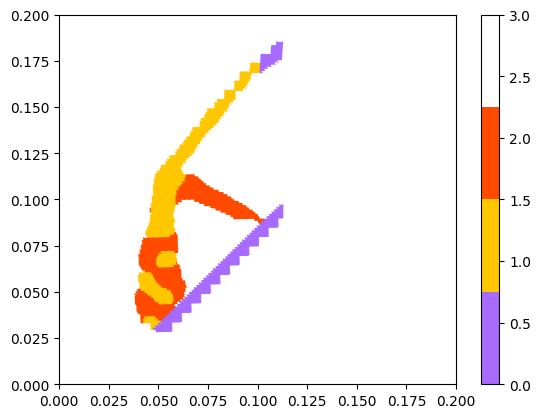

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.0738156430746917e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 4.997960454774125e-09
step 1/1
step 1/1
epoch 175 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 1.5918930661574718e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 5.610907418304631e-09
step 1/1
step 1/1
epoch 176 Loss -1.08E+00 J -4.62E-01 vf 0.01


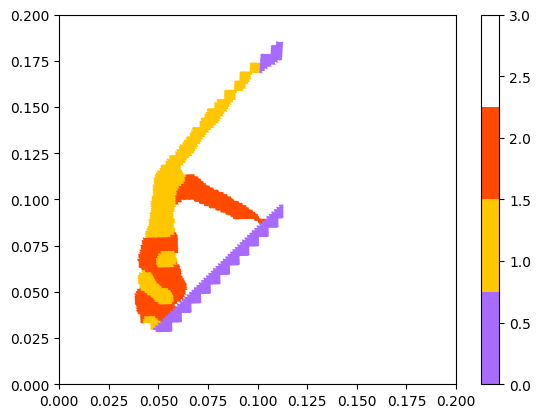

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 2.2730618371983136e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.18065108905541e-09
step 1/1
step 1/1
epoch 177 Loss -1.08E+00 J -4.62E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 3.1302047205832464e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 6.653132320978112e-09
step 1/1
step 1/1
epoch 178 Loss -1.08E+00 J -4.62E-01 vf 0.01


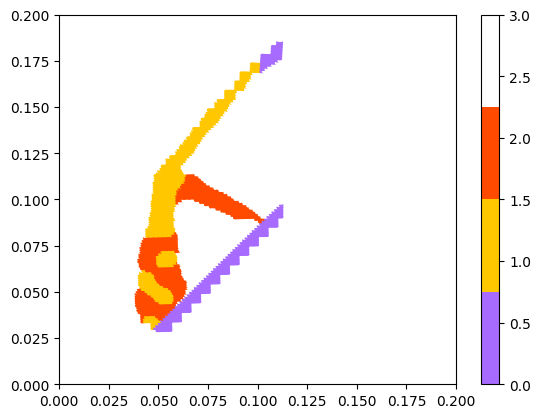

step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 4.192561164941276e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.016611478223287e-09
step 1/1
step 1/1
epoch 179 Loss -1.08E+00 J -4.63E-01 vf 0.01
step 1/1
NR converged in 7 iters, res_norm/res_norm_0: 5.4680718408903835e-09
step 1/1
NR converged in 8 iters, res_norm/res_norm_0: 7.269073384284808e-09
step 1/1


In [ ]:
mp_final, mat_fracs, net = optimize_design(
  net=topnet,
  mp_state0=mp_state,
  max_mass=max_mass,
  max_epoch=220,
  lr=1e-2,
  num_load_steps=1,
  gravity_vec=gravity_vec,
)

In [ ]:
plt.rcParams.update(_viz.high_res_plot_settings)
coords = np.asarray(mp_final.coord)
mat_idx = jnp.argmax(mat_fracs, axis=-1)

_, ax = plt.subplots()
img = ax.scatter(coords[:, 0], coords[:, 1], s=2, c=mat_idx, cmap=cmap)
ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# cbar = plt.colorbar(img, ax=ax, ticks=[0, 1, 2, 3])
# cbar.set_ticklabels(["0", "1", "2", "3"])  # optional, but explicit
ax.set_aspect("equal")

plt.show()


In [ ]:
num_mp_per_elem_per_dim = 4
bbox = _geom.BrepGeometry("moto/brep/rect_domain_expt_5.json")
high_res_mesh = _mesher.grid_mesh_brep(
  brep=bbox,
  nelx_desired=200,
  nely_desired=100,
  dofs_per_node=2,
  gauss_order=2,
)
inside = np.array(
  [prepared_beam_geom.covers(shap_geom.Point(xy)) for xy in high_res_mesh.elem_centers],
  dtype=bool,
)

# Element IDs to populate
occupied_element_ids = np.where(inside)[0]
mp_coords_high_res = _mesher.generate_mp_coords_in_occupied_elements(
  high_res_mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)
mp_xy_res = np.asarray(mp_coords_high_res)
mask_nd_res = np.array([nd_polygon.contains(shap_geom.Point(xy)) for xy in mp_xy_res])
nd_ids_np_res = np.where(mask_nd_res)[0].astype(np.int32)


if nd_ids_np.size == 0:
  raise ValueError(
    "No MPs in non-design bbox; increase height_non_design or check coordinates."
  )

nd_ids_res = jnp.asarray(nd_ids_np_res)

pts_xy_high_res = symm_map.apply(mp_coords_high_res)


pts_xy_high_res_fourier = fourier_proj.apply(pts_xy_high_res)
mat_fracs_high_res = jax.nn.softmax(net(pts_xy_high_res_fourier), axis=-1)

solid_vec = jax.nn.one_hot(
  solid_id, mat_fracs_high_res.shape[-1], dtype=mat_fracs_high_res.dtype
)  # (M,)
mat_fracs_high_res = mat_fracs_high_res.at[nd_ids_res].set(solid_vec)
mat_idx_high_res = jnp.argmax(mat_fracs_high_res, axis=-1)

_, ax = plt.subplots()
img = ax.scatter(
  mp_coords_high_res[:, 0], mp_coords_high_res[:, 1], s=2, c=mat_idx_high_res, cmap=cmap
)
ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
plt.show()